## Dataset Description
The dataset for this competition (both train and test) was generated from a deep learning model trained on the Flood Prediction Factors dataset. Feature distributions are close to, but not exactly the same, as the original. Feel free to use the original dataset as part of this competition, both to explore differences as well as to see whether incorporating the original in training improves model performance.

##### Note: This dataset is particularly well suited for visualizations, clustering, and general EDA. Show off your skills!

##### Files
* train.csv - the training dataset; FloodProbability is the target
* test.csv - the test dataset; your objective is to predict the FloodProbability for each row
* sample_submission.csv - a sample submission file in the correct form

In [1]:
# importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
import gc

In [ ]:
base_path = os.path.dirname(os.path.abspath(os.getcwd()))
print(base_path)
file_dir = os.path.join(base_path, 'Datasets', 'flood_prediction')

# reading datasets
train_df = pd.read_csv(rf'{file_dir}\train.csv')
test_df = pd.read_csv(rf'{file_dir}\test.csv')
sample_submission_df = pd.read_csv(rf'{file_dir}\sample_submission.csv')

In [3]:
print(f'Shape of Train Dataset: {train_df.shape}\n\n')
print(f'{train_df.info()}')

Shape of Train Dataset: (1117957, 22)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1117957 entries, 0 to 1117956
Data columns (total 22 columns):
 #   Column                           Non-Null Count    Dtype  
---  ------                           --------------    -----  
 0   id                               1117957 non-null  int64  
 1   MonsoonIntensity                 1117957 non-null  int64  
 2   TopographyDrainage               1117957 non-null  int64  
 3   RiverManagement                  1117957 non-null  int64  
 4   Deforestation                    1117957 non-null  int64  
 5   Urbanization                     1117957 non-null  int64  
 6   ClimateChange                    1117957 non-null  int64  
 7   DamsQuality                      1117957 non-null  int64  
 8   Siltation                        1117957 non-null  int64  
 9   AgriculturalPractices            1117957 non-null  int64  
 10  Encroachments                    1117957 non-null  int64  
 11  Ineffectiv

In [4]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 745305 entries, 0 to 745304
Data columns (total 21 columns):
 #   Column                           Non-Null Count   Dtype
---  ------                           --------------   -----
 0   id                               745305 non-null  int64
 1   MonsoonIntensity                 745305 non-null  int64
 2   TopographyDrainage               745305 non-null  int64
 3   RiverManagement                  745305 non-null  int64
 4   Deforestation                    745305 non-null  int64
 5   Urbanization                     745305 non-null  int64
 6   ClimateChange                    745305 non-null  int64
 7   DamsQuality                      745305 non-null  int64
 8   Siltation                        745305 non-null  int64
 9   AgriculturalPractices            745305 non-null  int64
 10  Encroachments                    745305 non-null  int64
 11  IneffectiveDisasterPreparedness  745305 non-null  int64
 12  DrainageSystems               

In [5]:
print(sample_submission_df.info())
del sample_submission_df
gc.collect()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 745305 entries, 0 to 745304
Data columns (total 2 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                745305 non-null  int64  
 1   FloodProbability  745305 non-null  float64
dtypes: float64(1), int64(1)
memory usage: 11.4 MB
None


0

so we need id in the submission dataset

In [6]:
test_df.head()

,id,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,...,IneffectiveDisasterPreparedness,DrainageSystems,CoastalVulnerability,Landslides,Watersheds,DeterioratingInfrastructure,PopulationScore,WetlandLoss,InadequatePlanning,PoliticalFactors
0,1117957,4,6,3,5,6,7,8,7,8,...,8,5,7,5,6,3,6,4,4,5
1,1117958,4,4,2,9,5,5,4,7,5,...,2,4,7,4,5,1,7,4,4,3
2,1117959,1,3,6,5,7,2,4,6,4,...,7,9,2,5,5,2,3,6,8,3
3,1117960,2,4,4,6,4,5,4,3,4,...,7,8,4,6,7,6,4,2,4,4
4,1117961,6,3,2,4,6,4,5,5,3,...,4,3,2,6,4,6,8,4,5,5


In [7]:
train_df.head()

,id,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,...,DrainageSystems,CoastalVulnerability,Landslides,Watersheds,DeterioratingInfrastructure,PopulationScore,WetlandLoss,InadequatePlanning,PoliticalFactors,FloodProbability
0,0,5,8,5,8,6,4,4,3,3,...,5,3,3,5,4,7,5,7,3,0.445
1,1,6,7,4,4,8,8,3,5,4,...,7,2,0,3,5,3,3,4,3,0.450
2,2,6,5,6,7,3,7,1,5,4,...,7,3,7,5,6,8,2,3,3,0.530
3,3,3,4,6,5,4,8,4,7,6,...,2,4,7,4,4,6,5,7,5,0.535
4,4,5,3,2,6,4,4,3,3,3,...,2,2,6,6,4,1,2,3,5,0.415


In [8]:
test_df.describe()

,id,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,...,IneffectiveDisasterPreparedness,DrainageSystems,CoastalVulnerability,Landslides,Watersheds,DeterioratingInfrastructure,PopulationScore,WetlandLoss,InadequatePlanning,PoliticalFactors
count,7.453050e+05,745305.000000,745305.000000,745305.000000,745305.000000,745305.000000,745305.000000,745305.000000,745305.000000,745305.000000,...,745305.000000,745305.000000,745305.000000,745305.000000,745305.000000,745305.000000,745305.000000,745305.000000,745305.000000,745305.000000
mean,1.490609e+06,4.915610,4.930288,4.960027,4.946084,4.938424,4.933524,4.958468,4.927651,4.945308,...,4.947436,4.944003,4.957209,4.927620,4.930720,4.926062,4.926957,4.948424,4.940204,4.943918
std,2.151512e+05,2.056295,2.094117,2.071722,2.052602,2.081816,2.059243,2.089312,2.068110,2.073404,...,2.081322,2.072335,2.088787,2.079006,2.083348,2.065638,2.073692,2.065891,2.079128,2.087387
min,1.117957e+06,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.304283e+06,3.000000,3.000000,4.000000,4.000000,3.000000,3.000000,4.000000,3.000000,3.000000,...,3.000000,4.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,3.000000,3.000000
50%,1.490609e+06,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000
75%,1.676935e+06,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,...,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000
max,1.863261e+06,16.000000,17.000000,16.000000,17.000000,17.000000,17.000000,16.000000,16.000000,16.000000,...,16.000000,17.000000,17.000000,16.000000,16.000000,17.000000,19.000000,22.000000,16.000000,16.000000


In [9]:
train_df.describe()

,id,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,...,DrainageSystems,CoastalVulnerability,Landslides,Watersheds,DeterioratingInfrastructure,PopulationScore,WetlandLoss,InadequatePlanning,PoliticalFactors,FloodProbability
count,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,...,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06
mean,5.589780e+05,4.921450e+00,4.926671e+00,4.955322e+00,4.942240e+00,4.942517e+00,4.934093e+00,4.955878e+00,4.927791e+00,4.942619e+00,...,4.946893e+00,4.953999e+00,4.931376e+00,4.929032e+00,4.925907e+00,4.927520e+00,4.950859e+00,4.940587e+00,4.939004e+00,5.044803e-01
std,3.227265e+05,2.056387e+00,2.093879e+00,2.072186e+00,2.051689e+00,2.083391e+00,2.057742e+00,2.083063e+00,2.065992e+00,2.068545e+00,...,2.072333e+00,2.088899e+00,2.078287e+00,2.082395e+00,2.064813e+00,2.074176e+00,2.068696e+00,2.081123e+00,2.090350e+00,5.102610e-02
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.850000e-01
25%,2.794890e+05,3.000000e+00,3.000000e+00,4.000000e+00,4.000000e+00,3.000000e+00,3.000000e+00,4.000000e+00,3.000000e+00,3.000000e+00,...,4.000000e+00,3.000000e+00,3.000000e+00,3.000000e+00,3.000000e+00,3.000000e+00,4.000000e+00,3.000000e+00,3.000000e+00,4.700000e-01
50%,5.589780e+05,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,...,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.050000e-01
75%,8.384670e+05,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,...,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,5.400000e-01
max,1.117956e+06,1.600000e+01,1.800000e+01,1.600000e+01,1.700000e+01,1.700000e+01,1.700000e+01,1.600000e+01,1.600000e+01,1.600000e+01,...,1.700000e+01,1.700000e+01,1.600000e+01,1.600000e+01,1.700000e+01,1.800000e+01,1.900000e+01,1.600000e+01,1.600000e+01,7.250000e-01


In [10]:
print(f'{train_df[:].max()}\n\n')
print(f'{test_df[:].max()}')

id                                 1117956.000
MonsoonIntensity                        16.000
TopographyDrainage                      18.000
RiverManagement                         16.000
Deforestation                           17.000
Urbanization                            17.000
ClimateChange                           17.000
DamsQuality                             16.000
Siltation                               16.000
AgriculturalPractices                   16.000
Encroachments                           18.000
IneffectiveDisasterPreparedness         16.000
DrainageSystems                         17.000
CoastalVulnerability                    17.000
Landslides                              16.000
Watersheds                              16.000
DeterioratingInfrastructure             17.000
PopulationScore                         18.000
WetlandLoss                             19.000
InadequatePlanning                      16.000
PoliticalFactors                        16.000
FloodProbabil

In [11]:
print(train_df.loc[train_df['FloodProbability']<=0.5, 'FloodProbability'].value_counts()[::-1],'\n\n')
print(train_df.loc[train_df['FloodProbability']>0.5, 'FloodProbability'].value_counts())

FloodProbability
0.285       20
0.315       42
0.335       48
0.325       61
0.320       79
0.330       82
0.340      243
0.345      250
0.355      377
0.350      515
0.360      625
0.365      989
0.375     1535
0.370     1615
0.380     1972
0.385     2266
0.390     3024
0.395     3875
0.400     5112
0.405     6954
0.410     8290
0.415    11156
0.420    11523
0.425    11618
0.430    14486
0.435    16428
0.440    20033
0.445    20482
0.450    26442
0.455    28541
0.465    31820
0.460    32583
0.470    37626
0.475    39773
0.500    40445
0.480    40815
0.485    41156
0.495    42302
0.490    43320
Name: count, dtype: int64 


FloodProbability
0.520    41266
0.505    41126
0.515    40876
0.510    40393
0.535    39466
0.530    38039
0.525    36562
0.540    35942
0.545    33579
0.550    28910
0.555    25633
0.560    23180
0.565    22073
0.570    19336
0.575    16848
0.580    14835
0.585    11761
0.590    10813
0.595     9721
0.600     7335
0.605     6539
0.610     5446
0.615     4275
0.620  

#### Insights on the dataset gathered so far

1. All the featues are numerical
2. All the features have max values around 16, 17, 18, 19
3. All the features are the related the natural enviroment (rain, Weather, ..) and construction (dam, drainage, ...)
4. Almost no outliers among all the features
5. Most probability is between 0.4 - 0.615 and max probability is 0.710

## Visualizing the features to find corelations and trends

In [12]:
# No need for id (for now) just increasing the computation cost and ram space
train_df.drop('id', axis=1, inplace = True)

In [13]:
train_df.columns

Index(['MonsoonIntensity', 'TopographyDrainage', 'RiverManagement',
       'Deforestation', 'Urbanization', 'ClimateChange', 'DamsQuality',
       'Siltation', 'AgriculturalPractices', 'Encroachments',
       'IneffectiveDisasterPreparedness', 'DrainageSystems',
       'CoastalVulnerability', 'Landslides', 'Watersheds',
       'DeterioratingInfrastructure', 'PopulationScore', 'WetlandLoss',
       'InadequatePlanning', 'PoliticalFactors', 'FloodProbability'],
      dtype='object')

*Creating scatterplots for all features with respect to FloodProbability*

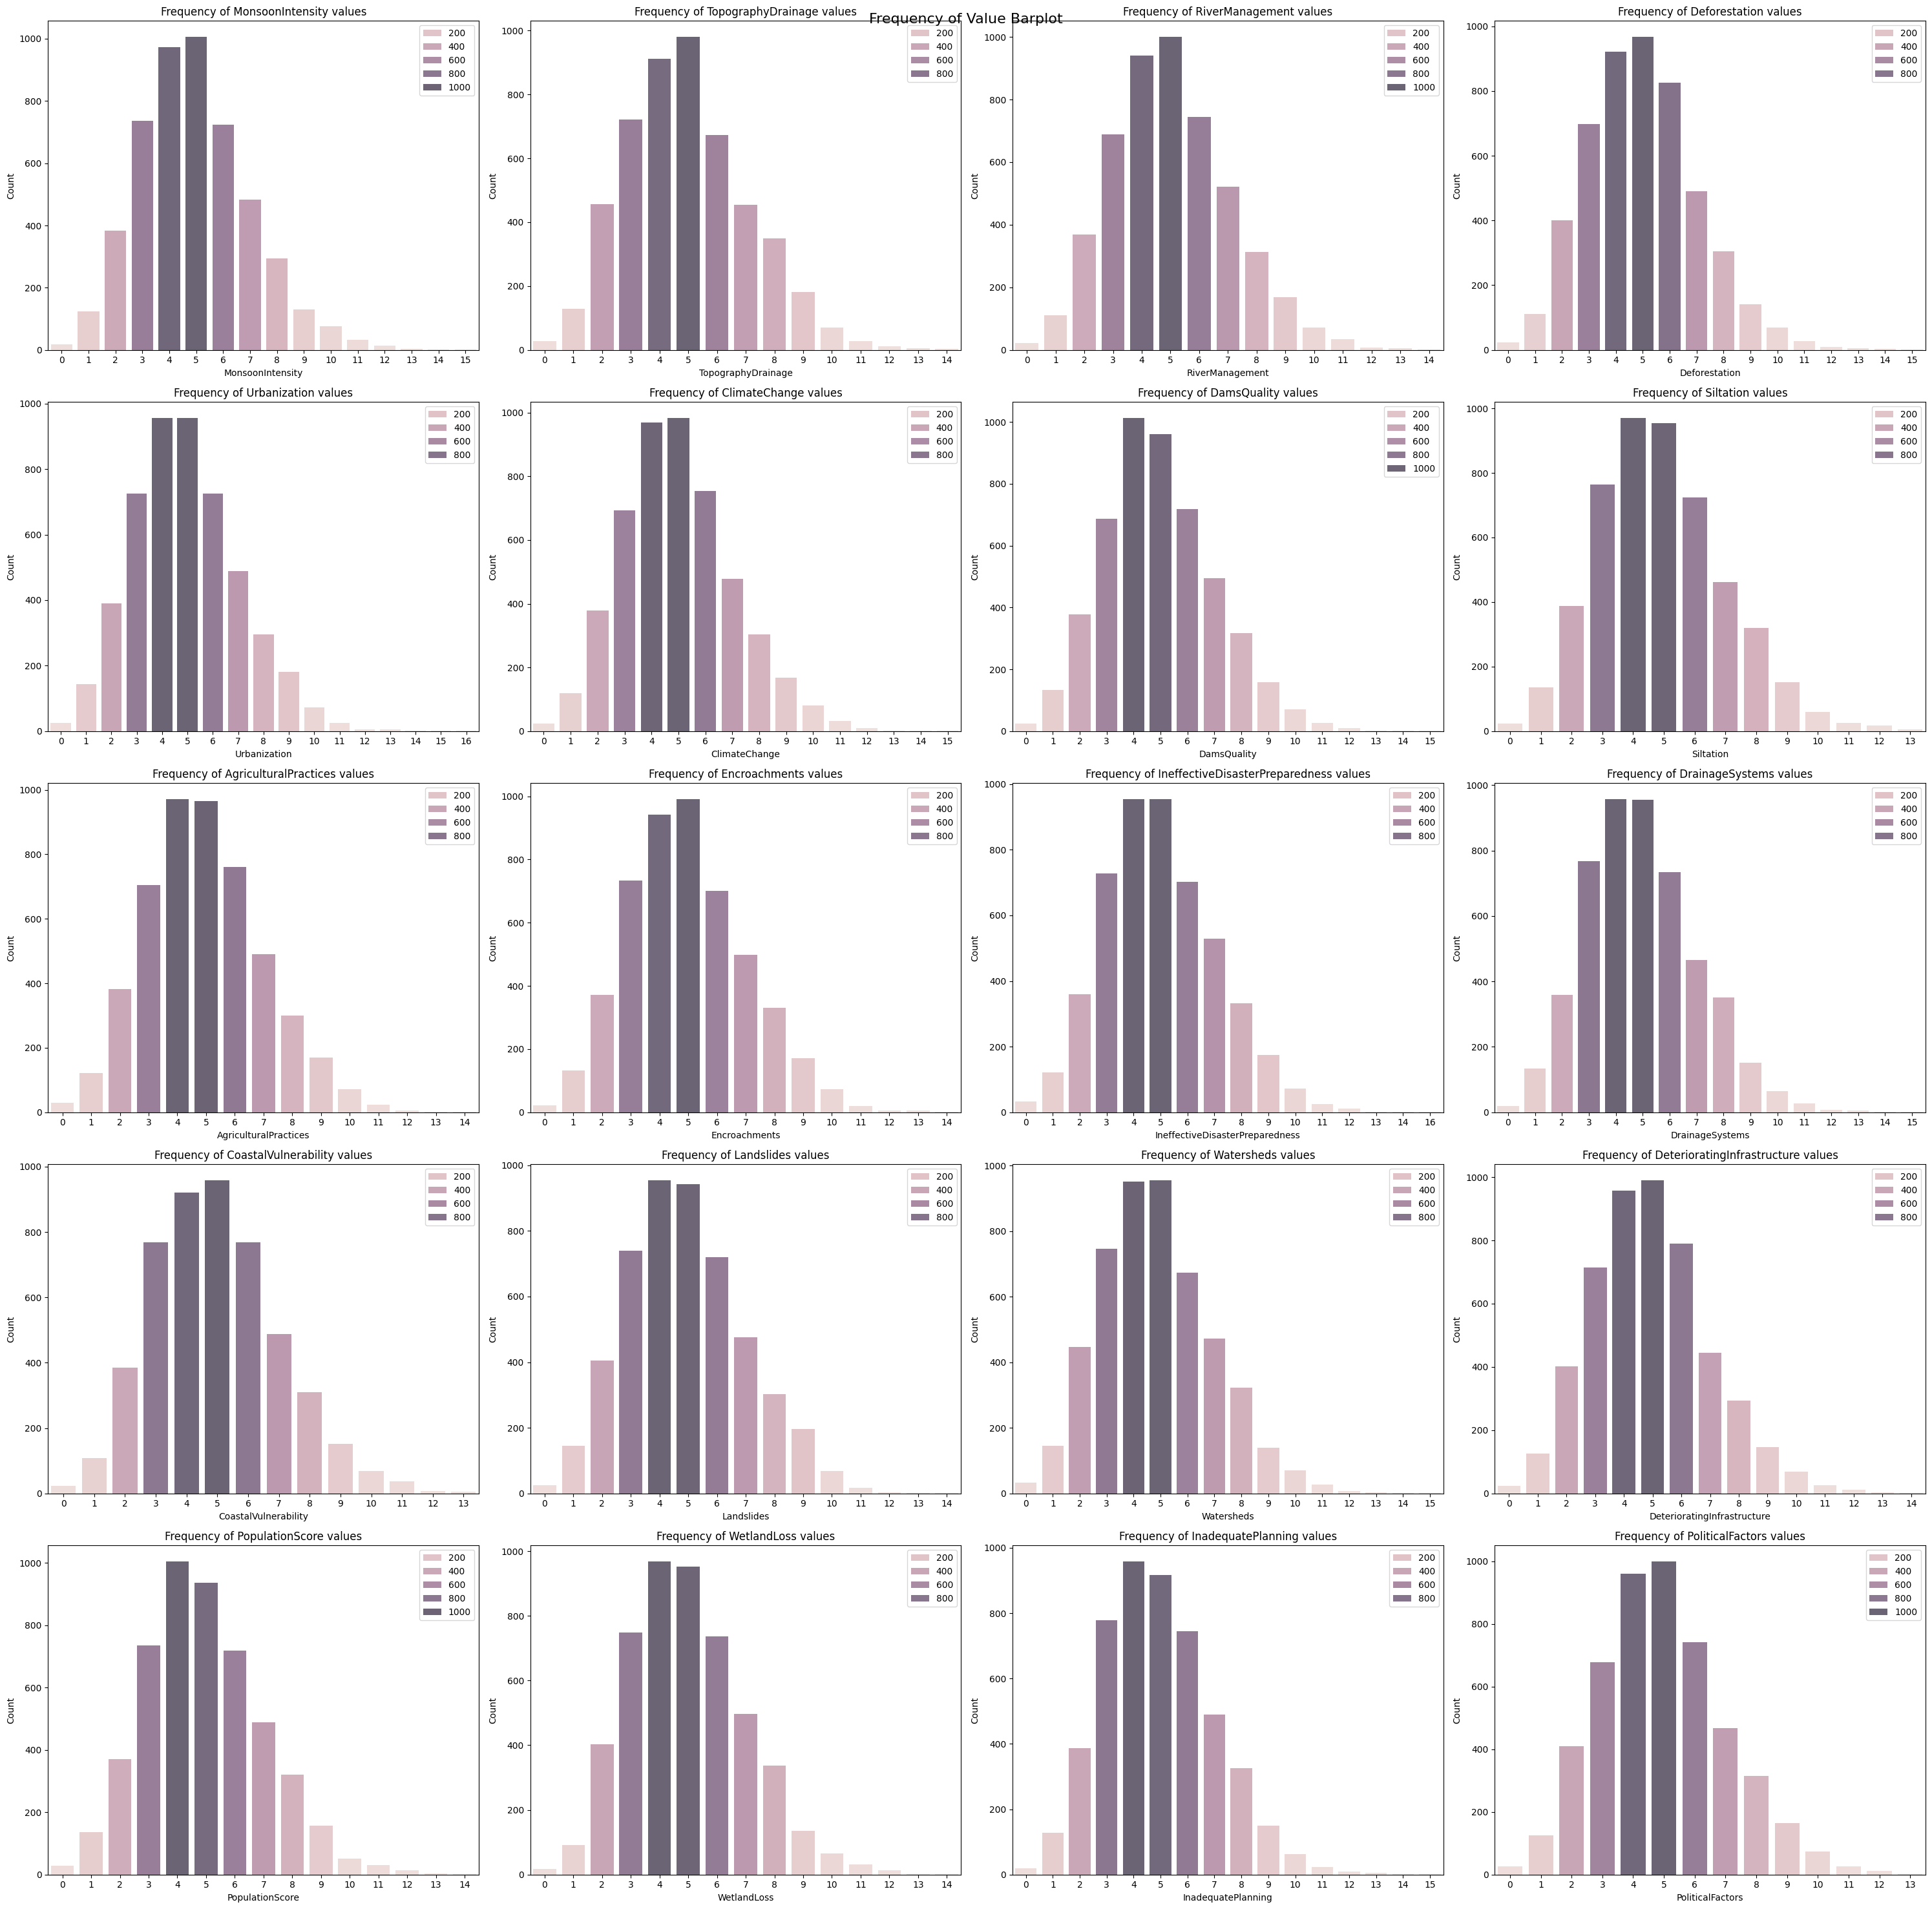

In [14]:
#filtering columns to be used in visualization
labels = [label for label in train_df.columns if label not in ['FloodProbability', 'id']]

n = len(labels)
size_df = 5000
# Deciding the grid size
n_columns = 4
n_rows = (n + n_columns - 1) // n_columns

fig, ax = plt.subplots(n_rows, n_columns, figsize=(30, 6 * n_rows))

ax = ax.flatten() # convert 2D -> 1D for easy indexing

sample_df = train_df.sample(size_df)

for i, label in enumerate(labels):
    # calculating frequency counts
    freq = sample_df[label].value_counts().sort_index()
    sns.barplot(   x=freq.index,
                    y=freq.values,
                    alpha=0.7,
                    hue=freq.values,
                    ax=ax[i])
    ax[i].set_title(f'Frequency of {label} values')
    ax[i].set_xlabel(label)
    ax[i].set_ylabel('Count')

# Remove extra empty plots
for j in range(i+1, len(ax)):
    fig.delaxes(ax[j])

fig.suptitle('Frequency of Value Barplot', fontsize=16)
plt.tight_layout()
plt.show()



*Creating historgarm plots for all the features with respect to FloodProbability*

In [15]:
# correlaation between the features
corr_mtx = train_df.corr()

print(f'Correlation of features wrt FloodProbability:\n\n{corr_mtx["FloodProbability"]}')

Correlation of features wrt FloodProbability:

MonsoonIntensity                   0.189098
TopographyDrainage                 0.187635
RiverManagement                    0.187131
Deforestation                      0.184001
Urbanization                       0.180861
ClimateChange                      0.184761
DamsQuality                        0.187996
Siltation                          0.186789
AgriculturalPractices              0.183366
Encroachments                      0.178841
IneffectiveDisasterPreparedness    0.183109
DrainageSystems                    0.179305
CoastalVulnerability               0.177774
Landslides                         0.185346
Watersheds                         0.181907
DeterioratingInfrastructure        0.190007
PopulationScore                    0.185890
WetlandLoss                        0.183396
InadequatePlanning                 0.180968
PoliticalFactors                   0.182417
FloodProbability                   1.000000
Name: FloodProbability, dtype

<Axes: >

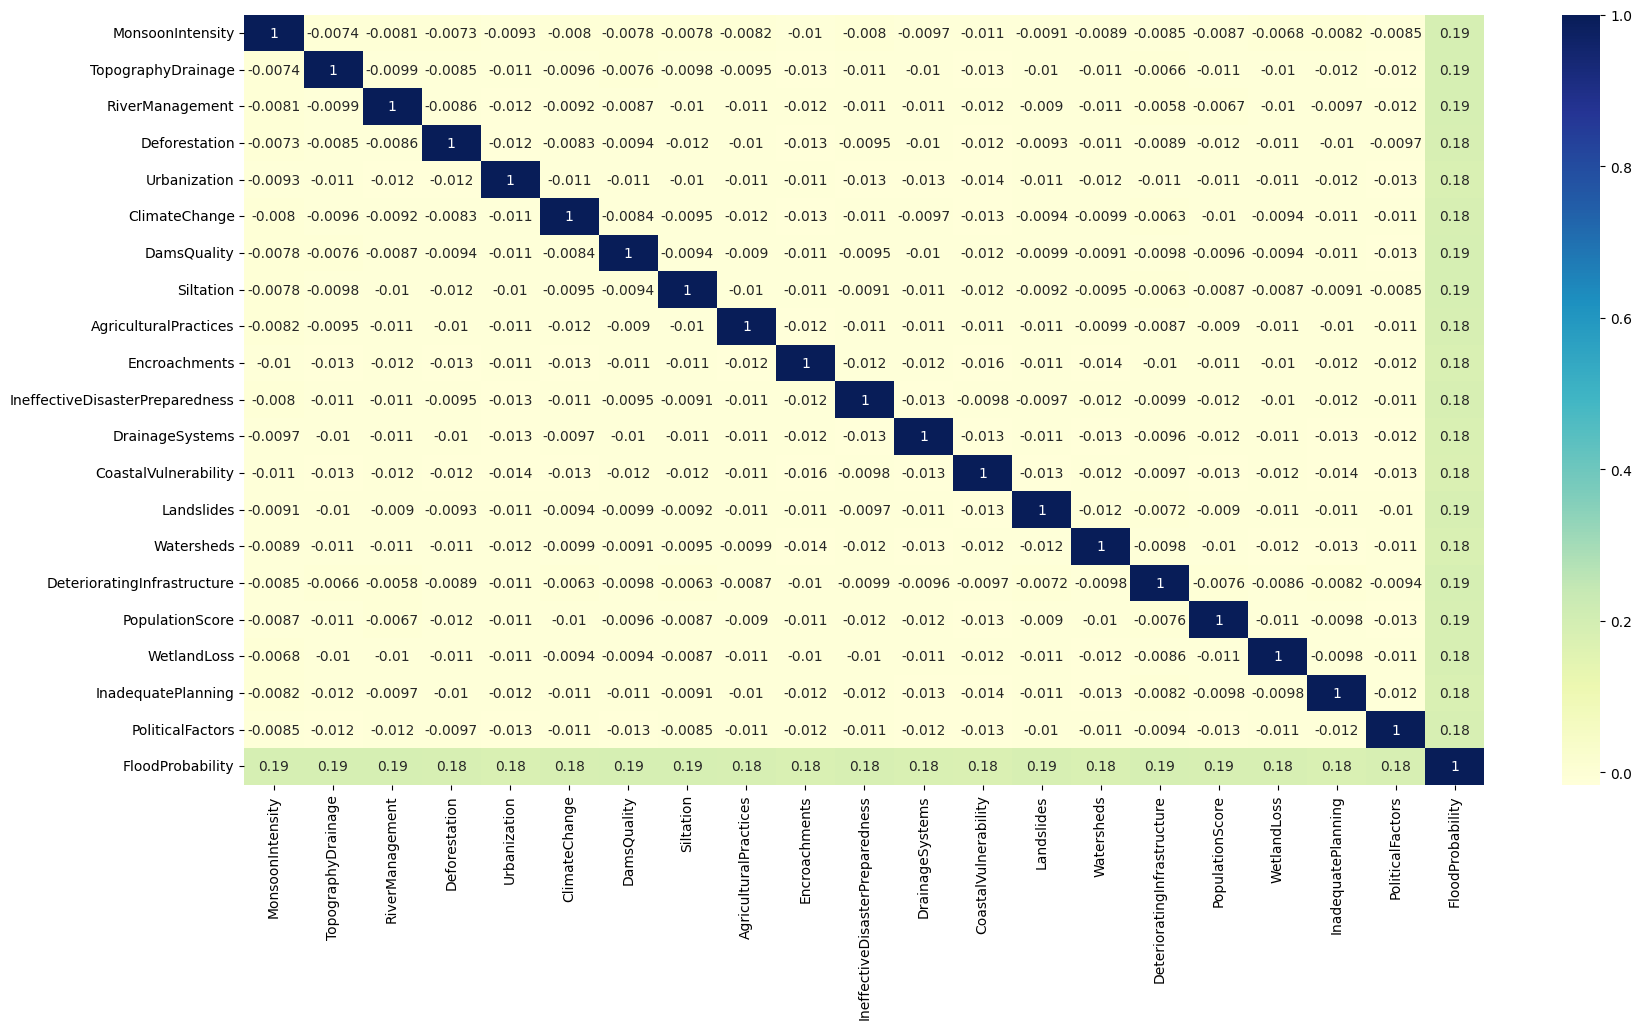

In [16]:
# Heatmap of the correlation between the features:
plt.figure(figsize=(20,10))
sns.heatmap(corr_mtx, cmap='YlGnBu', annot=True)

## Feature Engineering

##### 1. Creating a features from all the features to show the total impact analytics

* *TotalImpact - Sum of the row*
* *ImpactStd - Standard Deviation of the row*
* *ImpactMean - Mean of the row*
* *ImpactMedian - Median of the row*
* *ImpactMax - Max value of the row*
* *ImpactMin - Min value of hte row*
* *ImpactSkew - Skew of the row*
* *ImpactKurtosis - Kurtosis of the row*
* *Impact25 - 25% of the row*
* *Impact75 - 75% of the row*
* *ImpactIQR -*
* *ImpactCV - Cofficient of varation* (high variance rows = uneven risk distribution)

In [17]:
features = [col for col in train_df.columns if col not in ['id', 'FloodProbability']]

In [18]:
for df in [train_df, test_df]:
    # due to index misalignment between train and test DataFrames.
    df['TotalImpact'] = df[features].sum(axis=1)
    df['ImpactStd'] = df[features].std(axis=1)
    df['ImpactMean'] = df[features].mean(axis=1)
    df['ImpactMedian'] = df[features].median(axis=1)
    df['ImpactMin'] = df[features].min(axis=1)
    df['ImpactMax'] = df[features].max(axis=1)
    df['ImpactSkew'] = df[features].skew(axis=1)
    df['ImpactKurtosis'] = df[features].kurtosis(axis=1)
    df['ImpactCV'] = df['ImpactStd'] / (df['ImpactMean'] * 1e-6)
    
    # Percentile-Based Features
    df['Impact25'] = df[features].quantile(0.25, axis=1)
    df['Impact75'] = df[features].quantile(0.75, axis=1)
    df['ImpactIQR'] = df['Impact75'] - df['Impact25']      # not a useful feature only 0.07.. correlation

*TotalImpact is very important factor as correlation value is around 91.9%*

##### **2. Grouping features on the basis of the domains**

1. **Weather_FACTORS**:  = *MonsoonIntensity*, *WeatherChange*.


2. **GEOGRAPHY_FACTORS**: *TopographyDrainage*, *CoastalVulnerability*, *Landslides*, *Watersheds*.

3. **INFRASTRUCTURE**: *Urbanization*, *Deforestation*, *AgriculturalPractices*, *Encroachments*, *PopulationScore*.

4. **PLANING**: *IneffectiveDisasterPreparedness*, *InadequatePlanning*, *PoliticalFactors*, *WetlandLoss*.

In [19]:
train_df.columns

Index(['MonsoonIntensity', 'TopographyDrainage', 'RiverManagement',
       'Deforestation', 'Urbanization', 'ClimateChange', 'DamsQuality',
       'Siltation', 'AgriculturalPractices', 'Encroachments',
       'IneffectiveDisasterPreparedness', 'DrainageSystems',
       'CoastalVulnerability', 'Landslides', 'Watersheds',
       'DeterioratingInfrastructure', 'PopulationScore', 'WetlandLoss',
       'InadequatePlanning', 'PoliticalFactors', 'FloodProbability',
       'TotalImpact', 'ImpactStd', 'ImpactMean', 'ImpactMedian', 'ImpactMin',
       'ImpactMax', 'ImpactSkew', 'ImpactKurtosis', 'ImpactCV', 'Impact25',
       'Impact75', 'ImpactIQR'],
      dtype='object')

In [20]:
# Domain groupings
Weather_FACTORS = ['MonsoonIntensity', 'ClimateChange']
GEOGRAPHY_FACTORS = ['TopographyDrainage', 'CoastalVulnerability', 'Landslides', 'Watersheds']
HUMAN_FACTORS = ['Urbanization', 'Deforestation', 'AgriculturalPractices', 
                 'Encroachments', 'PopulationScore']
INFRASTRUCTURE = ['RiverManagement', 'DamsQuality', 'DrainageSystems', 
                  'DeterioratingInfrastructure', 'Siltation']
PLANNING = ['IneffectiveDisasterPreparedness', 'InadequatePlanning', 
              'PoliticalFactors', 'WetlandLoss']


for df in [train_df, test_df]:
    # TAKING SUM FOR TOTAL RISK CALCULATION
    df['InfrastructureRisk'] = df[INFRASTRUCTURE].sum(axis=1)
    df['WeatherRisk'] = df[Weather_FACTORS].sum(axis=1)
    df['PlanningRisk'] = df[PLANNING].sum(axis=1)
    df['GeographyRisk'] = df[GEOGRAPHY_FACTORS].sum(axis=1)
    df['HumanFRisk'] = df[HUMAN_FACTORS].sum(axis=1)

    # TAKING MEAN FOR AVERAGE SCORE CALCULATION
    df['InfrastructureAvgScore'] = df[INFRASTRUCTURE].mean(axis=1)
    df['WeatherAvgScore'] = df[Weather_FACTORS].mean(axis=1)
    df['PlanningAvgScore'] = df[PLANNING].mean(axis=1)
    df['GeographyAvgScore'] = df[GEOGRAPHY_FACTORS].mean(axis=1)
    df['HumanFAvgScore'] = df[HUMAN_FACTORS].mean(axis=1)
    
    

##### **3. Grouping features on the basis of Cross-Group**
* Using products to capture non-linaer relationships

In [21]:
for df in [train_df, test_df]:
    # Cross-group interactions (products capture non-linear relationships)
    df['Infra_x_Weather'] = df['InfrastructureAvgScore'] * df['WeatherAvgScore']
    df['Infra_x_Planning'] = df['InfrastructureAvgScore'] * df['PlanningAvgScore']
    df['Infra_x_Geography'] = df['InfrastructureAvgScore'] * df['GeographyAvgScore']
    df['Infra_x_HumanF'] = df['InfrastructureAvgScore'] * df['HumanFAvgScore']

    df['Weather_x_Geography'] = df['WeatherAvgScore'] * df['GeographyAvgScore']
    df['Weather_x_Planning'] = df['WeatherAvgScore'] * df['PlanningAvgScore']
    df['Weather_x_HumanF'] = df['WeatherAvgScore'] * df['HumanFAvgScore']
    
    df['Planning_x_Geography'] = df['PlanningAvgScore'] * df['GeographyAvgScore']
    df['Planning_x_HumanF'] = df['PlanningAvgScore'] * df['HumanFAvgScore']
    
    df['GeographyAvgScore'] = df['GeographyAvgScore'] * df['HumanFAvgScore']

##### **4. Creating Estimated Risk features**
It will be the sum of all the features according to  
1. **Low Risk Count**: Count of all the features with value <= 6
2. **Hight Risk Count**: Count of all the features with values greater than 6
3. **High Value Sum**: This feature will have sum of values from the feature if any value of them will be greater than 12

In [22]:
#----------Train Dataset----------
train_df['LowRiskCount'] = (train_df[features] <= 4).sum(axis=1)
train_df['HighRiskCount'] = (train_df[features] > 10).sum(axis=1)
train_df['HighValueSum'] = (train_df[features].where(train_df[features] >= 12, 0)).sum(axis=1)

#----------Test Dataset----------
test_df['LowRiskCount'] = (test_df[features] <= 4).sum(axis=1)
test_df['HighRiskCount'] = (test_df[features] > 10).sum(axis=1)
test_df['HighValueSum'] = test_df[features].where(test_df[features] >= 12, 0).sum(axis=1)


Adding two feature:
* HighRiskRatio  - ratio of 'bad' features to total (normalizes for scale)
* TotalImapctSq - Square of TotalImpact (Squares amlifies high values more than low ones)

##### Checking for correlation between the features

In [23]:
corr_mtx = train_df.corr()
corr_mtx['FloodProbability']

MonsoonIntensity                   0.189098
TopographyDrainage                 0.187635
RiverManagement                    0.187131
Deforestation                      0.184001
Urbanization                       0.180861
ClimateChange                      0.184761
DamsQuality                        0.187996
Siltation                          0.186789
AgriculturalPractices              0.183366
Encroachments                      0.178841
IneffectiveDisasterPreparedness    0.183109
DrainageSystems                    0.179305
CoastalVulnerability               0.177774
Landslides                         0.185346
Watersheds                         0.181907
DeterioratingInfrastructure        0.190007
PopulationScore                    0.185890
WetlandLoss                        0.183396
InadequatePlanning                 0.180968
PoliticalFactors                   0.182417
FloodProbability                   1.000000
TotalImpact                        0.919205
ImpactStd                       

In [24]:
# cols = [i for i in train_df.columns if i not in labels + ['FloodProbability', 'id']]
# n = len(cols)
# columns = 1
# rows = (n + columns -1)//columns

# fig, ax = plt.subplots(rows, columns, figsize=(20, 5*rows))
# ax = ax.flatten()
# sample_df = train_df.sample(2000)
# for i, col in enumerate(cols):
#     freq = sample_df[col].value_counts().sort_index()
#     sns.barplot(x = freq.index,
#                  y = freq.values,
#                  ax = ax[i],
#                  alpha=0.7,
#                  hue=freq.values)
    
#     ax[i].set_title(f'Frequency of {label} values')
#     ax[i].set_xlabel(label)
#     ax[i].set_ylabel('Count')

# # Remove extra empty plots
# for j in range(i+1, len(ax)):
#     fig.delaxes(ax[j])

# fig.suptitle('Frequency of Value Barplot', fontsize=16)
# plt.tight_layout()
# plt.show()


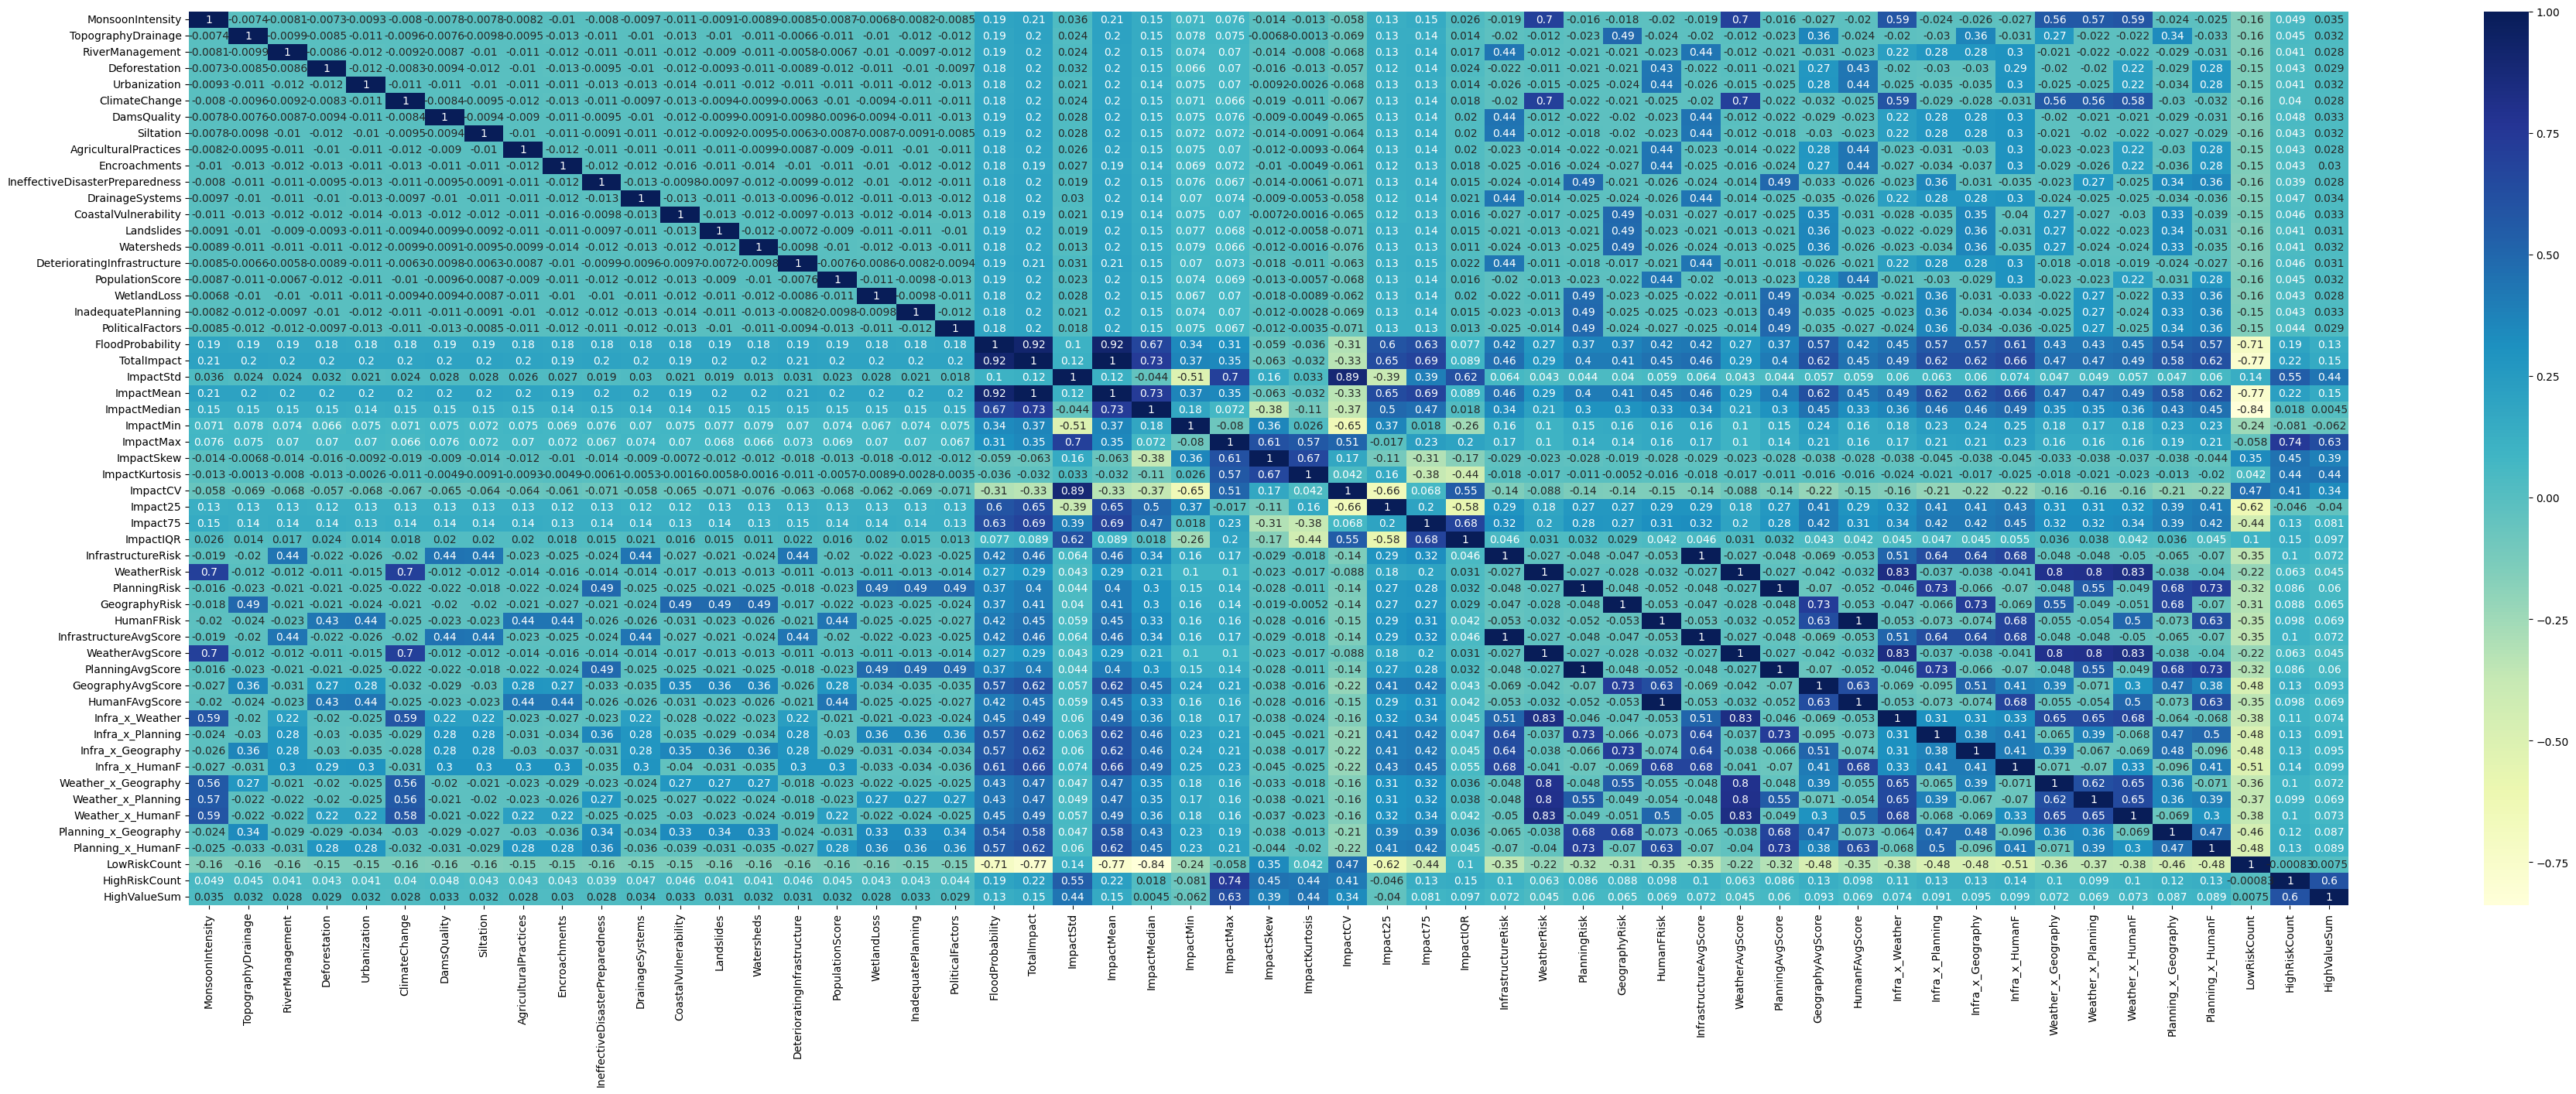

In [25]:
plt.figure(figsize=(45,15))
plt.tight_layout()
sns.heatmap(corr_mtx, cmap='YlGnBu', annot=True)
plt.show()

# Data Preprocessing

## Scaling

In [26]:
# Creating input and output columns

input_cols = train_df.columns.tolist()
input_cols.remove('FloodProbability')
target_col = 'FloodProbability'

print(input_cols)

['MonsoonIntensity', 'TopographyDrainage', 'RiverManagement', 'Deforestation', 'Urbanization', 'ClimateChange', 'DamsQuality', 'Siltation', 'AgriculturalPractices', 'Encroachments', 'IneffectiveDisasterPreparedness', 'DrainageSystems', 'CoastalVulnerability', 'Landslides', 'Watersheds', 'DeterioratingInfrastructure', 'PopulationScore', 'WetlandLoss', 'InadequatePlanning', 'PoliticalFactors', 'TotalImpact', 'ImpactStd', 'ImpactMean', 'ImpactMedian', 'ImpactMin', 'ImpactMax', 'ImpactSkew', 'ImpactKurtosis', 'ImpactCV', 'Impact25', 'Impact75', 'ImpactIQR', 'InfrastructureRisk', 'WeatherRisk', 'PlanningRisk', 'GeographyRisk', 'HumanFRisk', 'InfrastructureAvgScore', 'WeatherAvgScore', 'PlanningAvgScore', 'GeographyAvgScore', 'HumanFAvgScore', 'Infra_x_Weather', 'Infra_x_Planning', 'Infra_x_Geography', 'Infra_x_HumanF', 'Weather_x_Geography', 'Weather_x_Planning', 'Weather_x_HumanF', 'Planning_x_Geography', 'Planning_x_HumanF', 'LowRiskCount', 'HighRiskCount', 'HighValueSum']


In [27]:
# Creating input and output datasets to scaler and other processes
target = train_df[target_col]
input_df = train_df[input_cols]

test_input_df = test_df[input_cols]

In [28]:
from sklearn.preprocessing import MinMaxScaler

# ✅ FIX Bug 3: Fit scaler ONLY on training data
# Previously a separate scaler was fitted on test_input_df, which caused
# a different value range for test vs train — the model saw foreign distributions.
scaler = MinMaxScaler().fit(input_df)


In [29]:
# input_df[input_cols] = scaler.transform(input_df[input_cols])
# test_input_df = scaler.transform(test_input_df[input_cols])

In [30]:
input_df = pd.DataFrame(
    scaler.transform(input_df[input_cols]),
    columns=input_cols,
    index=input_df.index
)

test_input_df = pd.DataFrame(
    scaler.transform(test_input_df[input_cols]),
    columns=input_cols,
    index=test_input_df.index      # preserve original index
)

In [31]:
input_df.head()

,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,Encroachments,...,Infra_x_Geography,Infra_x_HumanF,Weather_x_Geography,Weather_x_Planning,Weather_x_HumanF,Planning_x_Geography,Planning_x_HumanF,LowRiskCount,HighRiskCount,HighValueSum
0,0.3125,0.444444,0.3125,0.470588,0.352941,0.235294,0.2500,0.1875,0.1875,0.222222,...,0.227074,0.283930,0.218670,0.19125,0.286364,0.229117,0.272611,0.50,0.0,0.0
1,0.3750,0.388889,0.2500,0.235294,0.470588,0.470588,0.1875,0.3125,0.2500,0.333333,...,0.157829,0.290744,0.214834,0.33250,0.397727,0.153540,0.271969,0.55,0.0,0.0
2,0.3750,0.277778,0.3750,0.411765,0.176471,0.411765,0.0625,0.3125,0.2500,0.277778,...,0.290081,0.333333,0.332481,0.22750,0.398864,0.194909,0.209750,0.35,0.0,0.0
3,0.1875,0.222222,0.3750,0.294118,0.235294,0.470588,0.2500,0.4375,0.3750,0.444444,...,0.250780,0.328790,0.267263,0.30250,0.362500,0.304694,0.376523,0.40,0.0,0.0
4,0.3125,0.166667,0.1250,0.352941,0.235294,0.235294,0.1875,0.1875,0.1875,0.166667,...,0.126638,0.085179,0.195652,0.16875,0.173864,0.175020,0.130853,0.70,0.0,0.0


## Train/Validation Split

In [32]:
from sklearn.model_selection import train_test_split

print('Shape of input and output columns BEFORE spliting into train and validation dataset:\n')
print(f'Shape of input dataset: {input_df.shape}')
print(f'Shape of output dataset: {target.shape}\n')

X_train, X_val, Y_train, Y_val = train_test_split(input_df, target, test_size=0.3, random_state=57)

print('Shape of input and output columns AFTER spliting into train and validation dataset:\n')
print(f'Shape of TRAIN INPUT dataset: {X_train.shape}')
print(f'Shape of Train OUTPUT dataset: {Y_train.shape}\n')

print(f'Shape of VAL INPUT dataset: {X_val.shape}')
print(f'Shape of VAL OUTPUT dataset: {Y_val.shape}')

Shape of input and output columns BEFORE spliting into train and validation dataset:

Shape of input dataset: (1117957, 54)
Shape of output dataset: (1117957,)

Shape of input and output columns AFTER spliting into train and validation dataset:

Shape of TRAIN INPUT dataset: (782569, 54)
Shape of Train OUTPUT dataset: (782569,)

Shape of VAL INPUT dataset: (335388, 54)
Shape of VAL OUTPUT dataset: (335388,)


In [34]:
folder_path = r'D:\Codes\Artificial_Intelligence\Machine_Learning\Scikit_Learn\Projects\Train_Val_Test_Ouptut'
X_train.to_csv(fr'{folder_path}\X_train.csv', index=False)
Y_train.to_csv(fr'{folder_path}\Y_train.csv', index=False)

X_val.to_csv(fr'{folder_path}\X_test.csv', index=False)
Y_val.to_csv(fr'{folder_path}\Y_val.csv', index=False)

test_input_df.to_csv(fr'{folder_path}\test_input_df.csv', index=False)

Successfully created ready to feed final input and output datasets for our model

## Model Creation

In [35]:
import xgboost
from sklearn.metrics import root_mean_squared_error as rmse, r2_score, mean_absolute_percentage_error as mape

# XGB Regressor Model

In [36]:
# xgb = xgboost.XGBRegressor(random_state=57,
#                            n_estimators=300,
#                            objective='reg:squarederror',
#                            max_depth=7,
#                            verbose=10
#                            )

In [ ]:
xgb_params = {
    'random_state': 577,
    'n_estimators': 1000,
    'booster': 'gbtree',
    'learning_rate': 0.05,         # 0.05 is a sweet spot
    'max_depth': 7,
    'objective': 'reg:squarederror',
    'tree_method': 'hist',
    'device': 'cpu',               # Change to 'cuda' if you have a GPU
    'gamma': 0.2,
    'min_child_weight': 12,
    'subsample': 0.9,
    'colsample_bytree': 0.8,
    'reg_alpha': 0.1,
    'reg_lambda': 1.0,
    'n_jobs': -1,
    'base_score': 0.5,
    'verbosity': 2,
    'early_stopping_rounds': 50,
}

xgb = xgboost.XGBRegressor(**xgb_params)


In [38]:
xgb.fit(X_train, Y_train, 
        eval_set=[(X_val, Y_val)],
        verbose=100)

[09:41:20] INFO: C:\actions-runner\_work\xgboost\xgboost\src\data\iterative_dmatrix.cc:56: Finished constructing the `IterativeDMatrix`: (782569, 54, 42258726).
[09:41:21] INFO: C:\actions-runner\_work\xgboost\xgboost\src\data\iterative_dmatrix.cc:56: Finished constructing the `IterativeDMatrix`: (335388, 54, 18110952).
[0]	validation_0-rmse:0.04900
[100]	validation_0-rmse:0.01871
[182]	validation_0-rmse:0.01871


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",0.5
,booster,'gbtree'
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",'cpu'
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",50
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabete

In [39]:
train_pred = xgb.predict(X_train)
val_pred = xgb.predict(X_val)

In [40]:
train_rmse = rmse(y_true=Y_train, y_pred=train_pred)
val_rmse = rmse(y_true=Y_val, y_pred=val_pred)

print(f'Train RootMeanSquareError: {train_rmse}')
print(f'Validation RootMeanSquareError: {val_rmse}')

Train RootMeanSquareError: 0.018705194486561705
Validation RootMeanSquareError: 0.018708127131792544


In [41]:
train_r2s = r2_score(y_pred=train_pred, y_true=Y_train)
val_r2s = r2_score(y_pred=val_pred, y_true=Y_val)

print(f'Train R² Score: {train_r2s}')
print(f'Validation R² Score: {val_r2s}')

Train R² Score: 0.8656426077018172
Validation R² Score: 0.8655191109263046


##### max_depth = 7, n_estimators = 1000
* RMSE:
    * Train RootMeanSquareError: 0.018699898237821637
    * Validation RootMeanSquareError: 0.0187078024399395

* R2 Score:
    * Train R² Score: 0.8656899553259216
    * Validation R² Score: 0.8655940618526341



## Visualisation of the Perdiction and Targets

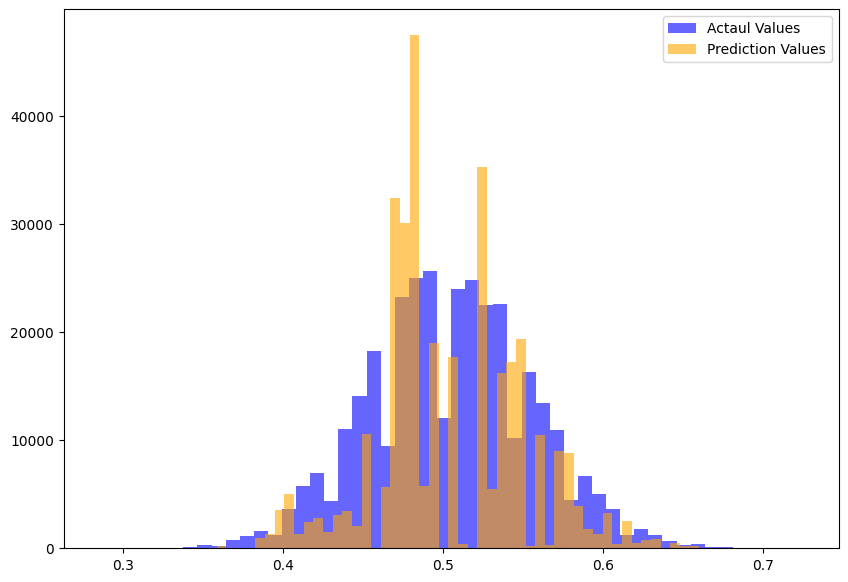

In [42]:
plt.figure(figsize=(10,7))
plt.hist(Y_val.values, bins=50, alpha=0.6, label='Actaul Values', color='blue')
plt.hist(val_pred, bins=50, alpha=0.6, label='Prediction Values', color='orange')
plt.legend()
plt.show()

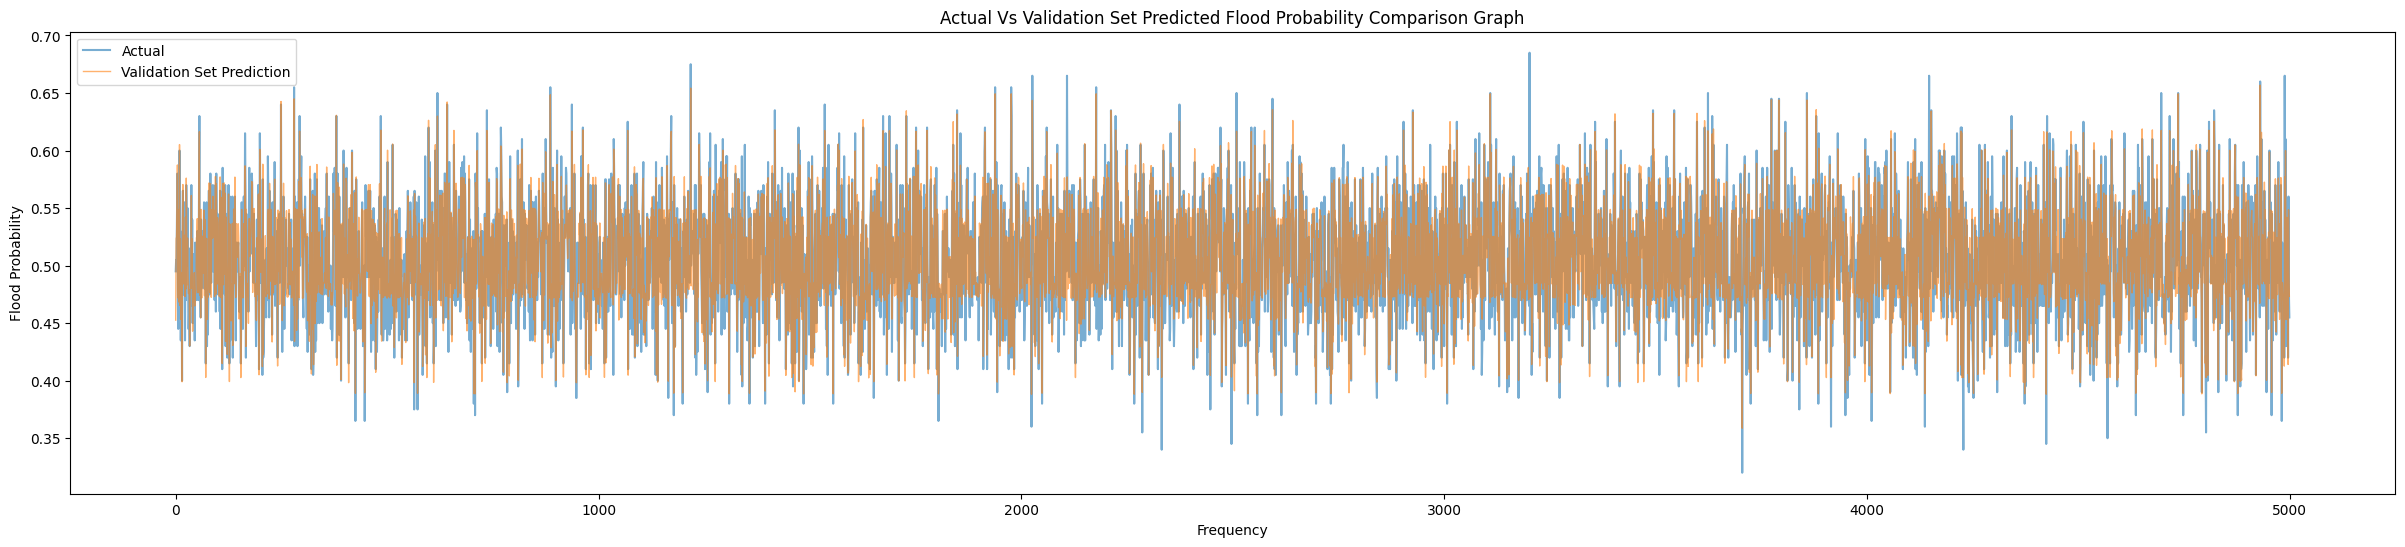

In [43]:
plt.figure(figsize=(30,6))
plt.plot(Y_val.values[:5000], alpha=0.6, label='Actual', linewidth=1.5)
plt.plot(val_pred[:5000], alpha=0.6, label='Validation Set Prediction', linewidth=1)
plt.legend()
plt.xlabel('Frequency')
plt.ylabel('Flood Probability')
plt.title('Actual Vs Validation Set Predicted Flood Probability Comparison Graph')
plt.show()

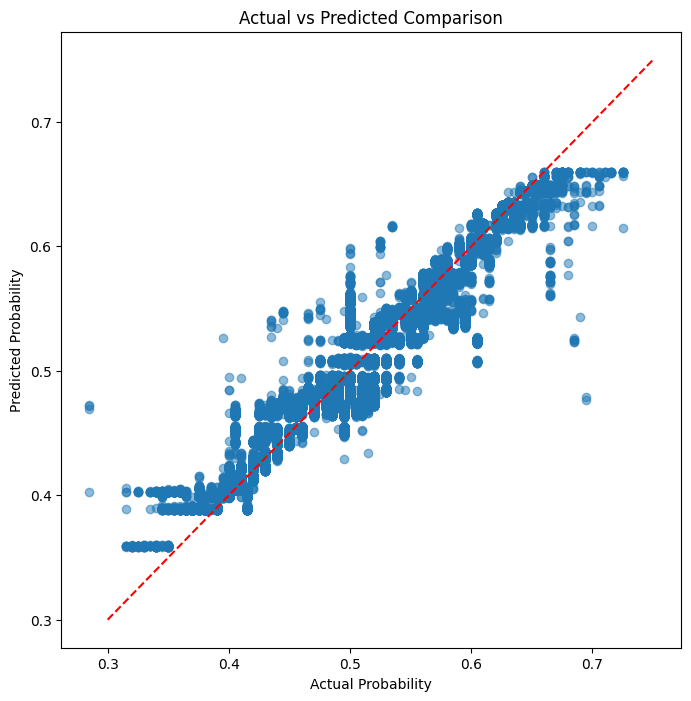

In [44]:
plt.figure(figsize=(8,8))
plt.scatter(Y_val, val_pred, alpha=0.5)
plt.plot([0.3, 0.75], [0.3, 0.75], color='red', linestyle='--') # Identity line
plt.xlabel('Actual Probability')
plt.ylabel('Predicted Probability')
plt.title('Actual vs Predicted Comparison')
plt.show()

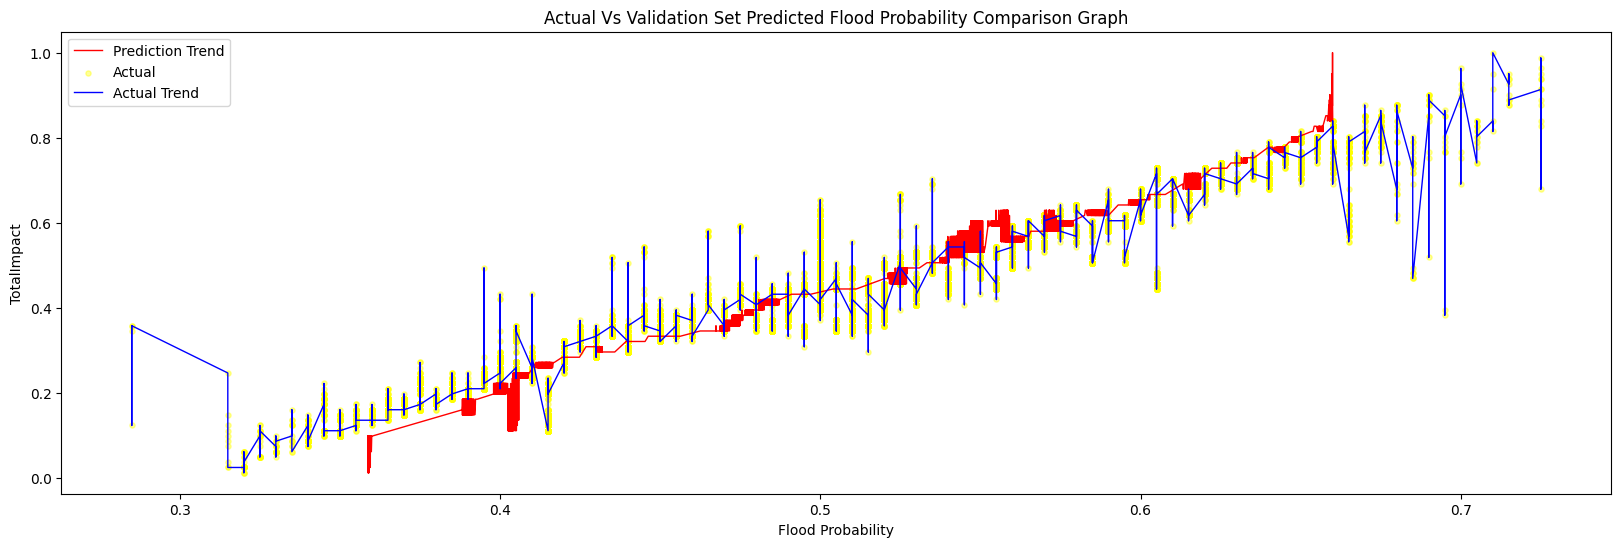

In [45]:
plt.figure(figsize=(20,6))
sort_idx = np.argsort(val_pred)

plt.plot(val_pred[sort_idx], X_val['TotalImpact'].iloc[sort_idx], color='red', label='Prediction Trend', linewidth=1)

plt.scatter(Y_val, X_val['TotalImpact'], alpha=0.4, label='Actual', s=14, color='yellow')

sort_idx = np.argsort(Y_val)
plt.plot(Y_val.iloc[sort_idx], X_val['TotalImpact'].iloc[sort_idx], color='blue', label='Actual Trend', linewidth=1)

plt.legend()
plt.xlabel('Flood Probability')
plt.ylabel('TotalImpact')
plt.title('Actual Vs Validation Set Predicted Flood Probability Comparison Graph')
plt.show()

# LightXGBoost

In [46]:
from lightgbm import LGBMRegressor, early_stopping, log_evaluation

In newer LightGBM versions (≥ 4.0), early_stopping_rounds and verbose were removed from .fit() and moved to callbacks.

In [47]:
lgbmr = LGBMRegressor(n_estimators=1000,
                      random_state=980,
                      n_jobs=-1,
                      learning_rate=0.05,
                      subsample=0.9,
                      min_child_samples=7,
                      max_depth=7,
                      num_leaves=50,
                      colsample_bytree=0.9,
                      reg_alpha=0.4,
                      reg_lambda=0.4,
                      objective='regression'
                      )

In [48]:
lgbmr.fit(X_train, Y_train,
          eval_metric='rmse',
          eval_set=[(X_val, Y_val)],
          callbacks=[
              early_stopping(stopping_rounds=100,),
              log_evaluation(period=50)
          ])

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.106292 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4502
[LightGBM] [Info] Number of data points in the train set: 782569, number of used features: 54
[LightGBM] [Info] Start training from score 0.504505
Training until validation scores don't improve for 100 rounds
[50]	valid_0's rmse: 0.0188917	valid_0's l2: 0.000356898
[100]	valid_0's rmse: 0.0184874	valid_0's l2: 0.000341784
[150]	valid_0's rmse: 0.0184774	valid_0's l2: 0.000341415
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[200]	valid_0's rmse: 0.018475	valid_0's l2: 0.000341327
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[250]	valid_0's rmse: 0.0184742	valid_0's l2: 0.000341296
[LightG

,boosting_type,'gbdt'
,num_leaves,50
,max_depth,7
,learning_rate,0.05
,n_estimators,1000
,subsample_for_bin,200000
,objective,'regression'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,7


In [49]:
train_pred = lgbmr.predict(X_train)
val_pred = lgbmr.predict(X_val)

In [50]:
train_rmse = rmse(y_true=Y_train, y_pred=train_pred)
val_rmse = rmse(y_true=Y_val, y_pred=val_pred)

print(f'Train RootMeanSquareError: {train_rmse}')
print(f'Validation RootMeanSquareError: {val_rmse}')

Train RootMeanSquareError: 0.01829878240518112
Validation RootMeanSquareError: 0.0184727233217485


In [51]:
train_r2s = r2_score(y_pred=train_pred, y_true=Y_train)
val_r2s = r2_score(y_pred=val_pred, y_true=Y_val)

print(f'Train R² Score: {train_r2s}')
print(f'Validation R² Score: {val_r2s}')

Train R² Score: 0.8714176094589787
Validation R² Score: 0.8688821565079341


##### max_depth = 7, n_estimators = 1000
* RMSE:
    * Train RootMeanSquareError: 0.018699898237821637
    * Validation RootMeanSquareError: 0.0187078024399395

* R2 Score:
    * Train R² Score: 0.8656899553259216
    * Validation R² Score: 0.8655940618526341



## Visualisation of the Perdiction and Targets

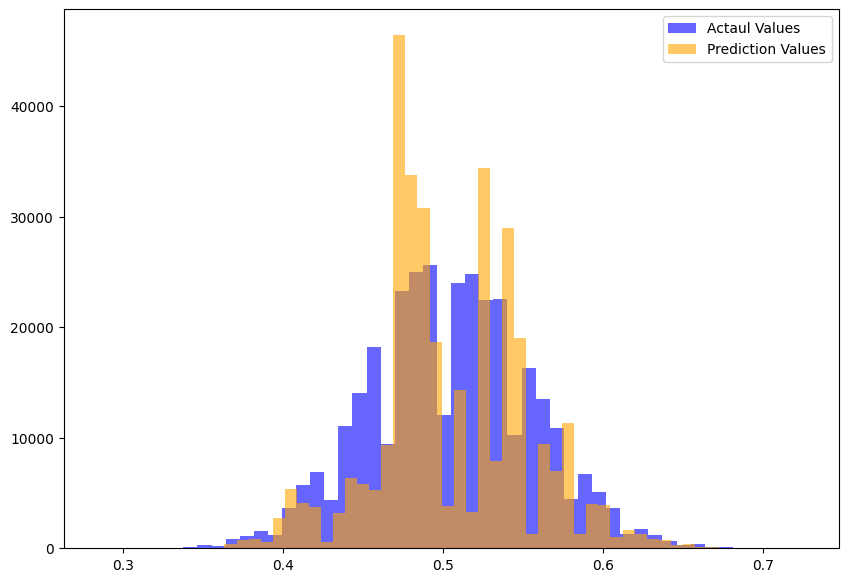

In [52]:
plt.figure(figsize=(10,7))
plt.hist(Y_val.values, bins=50, alpha=0.6, label='Actaul Values', color='blue')
plt.hist(val_pred, bins=50, alpha=0.6, label='Prediction Values', color='orange')
plt.legend()
plt.show()

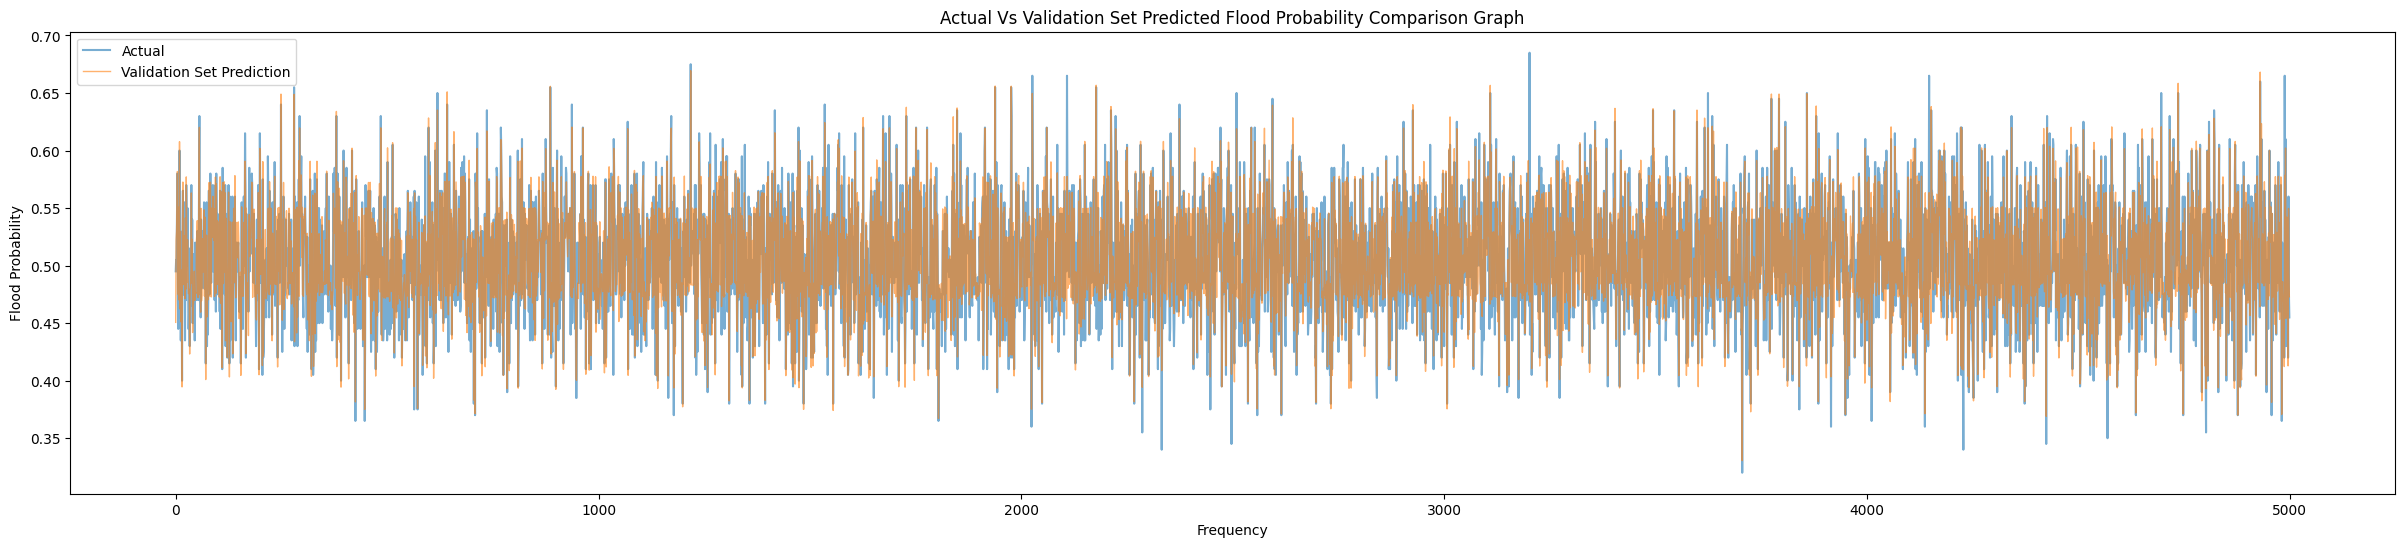

In [53]:
plt.figure(figsize=(30,6))
plt.plot(Y_val.values[:5000], alpha=0.6, label='Actual', linewidth=1.5)
plt.plot(val_pred[:5000], alpha=0.6, label='Validation Set Prediction', linewidth=1)
plt.legend()
plt.xlabel('Frequency')
plt.ylabel('Flood Probability')
plt.title('Actual Vs Validation Set Predicted Flood Probability Comparison Graph')
plt.show()

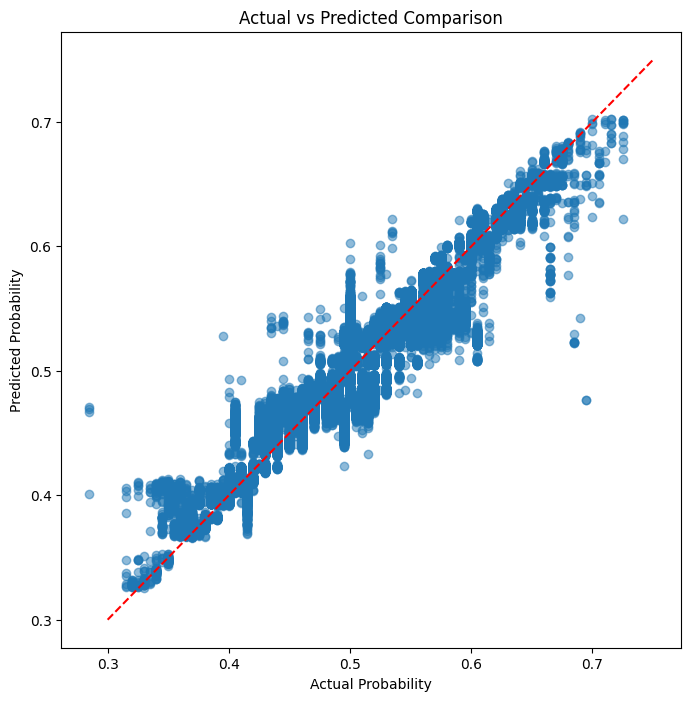

In [54]:
plt.figure(figsize=(8,8))
plt.scatter(Y_val, val_pred, alpha=0.5)
plt.plot([0.3, 0.75], [0.3, 0.75], color='red', linestyle='--') # Identity line
plt.xlabel('Actual Probability')
plt.ylabel('Predicted Probability')
plt.title('Actual vs Predicted Comparison')
plt.show()

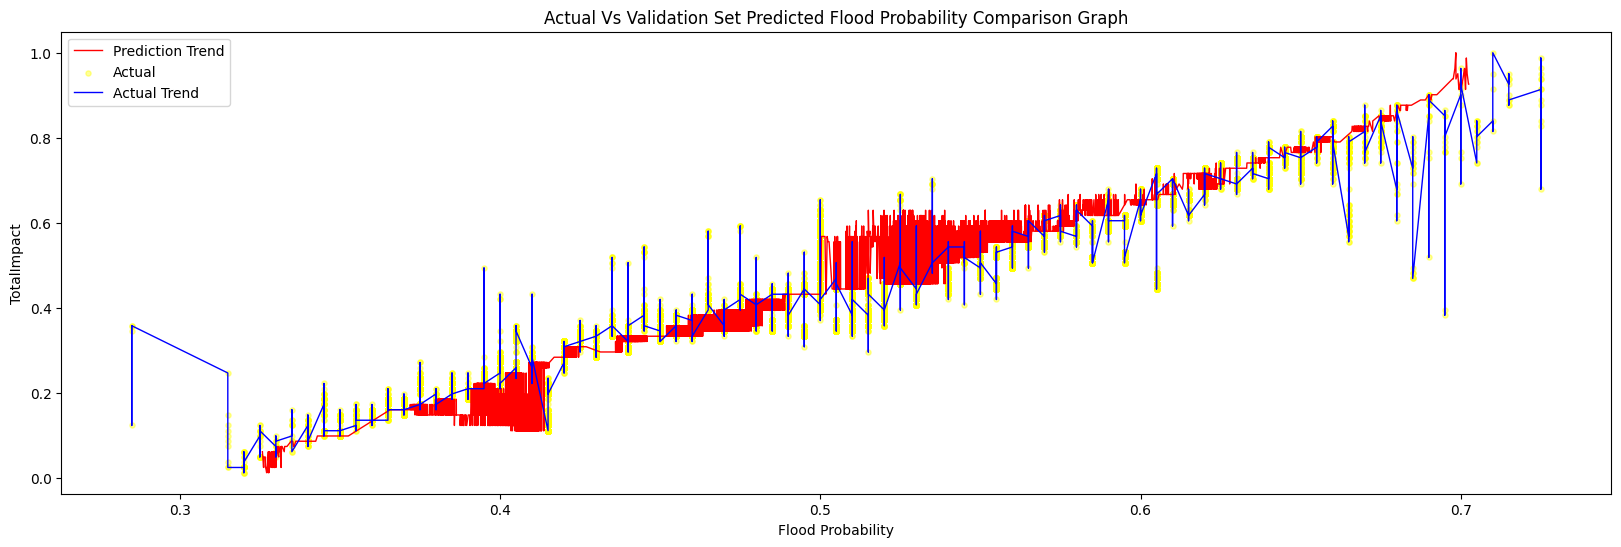

In [55]:
plt.figure(figsize=(20,6))
sort_idx = np.argsort(val_pred)

plt.plot(val_pred[sort_idx], X_val['TotalImpact'].iloc[sort_idx], color='red', label='Prediction Trend', linewidth=1)

plt.scatter(Y_val, X_val['TotalImpact'], alpha=0.4, label='Actual', s=14, color='yellow')

sort_idx = np.argsort(Y_val)
plt.plot(Y_val.iloc[sort_idx], X_val['TotalImpact'].iloc[sort_idx], color='blue', label='Actual Trend', linewidth=1)

plt.legend()
plt.xlabel('Flood Probability')
plt.ylabel('TotalImpact')
plt.title('Actual Vs Validation Set Predicted Flood Probability Comparison Graph')
plt.show()

# Linear Regression

In [56]:
from sklearn.linear_model import LinearRegression

In [57]:
linearReg = LinearRegression(n_jobs=-1)
linearReg.fit(X_train, Y_train,)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",-1
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [58]:
train_pred = linearReg.predict(X_train)
val_pred = linearReg.predict(X_val)

In [59]:
train_rmse = rmse(y_true=Y_train, y_pred=train_pred)
val_rmse = rmse(y_true=Y_val, y_pred=val_pred)

print(f'Train RootMeanSquareError: {train_rmse}')
print(f'Validation RootMeanSquareError: {val_rmse}')

Train RootMeanSquareError: 0.02005702783043085
Validation RootMeanSquareError: 0.020052831351485077


In [60]:
train_r2s = r2_score(y_pred=train_pred, y_true=Y_train)
val_r2s = r2_score(y_pred=val_pred, y_true=Y_val)

print(f'Train R² Score: {train_r2s}')
print(f'Validation R² Score: {val_r2s}')

Train R² Score: 0.8455207102013101
Validation R² Score: 0.8454918654027939


## Visualisation of the Perdiction and Targets

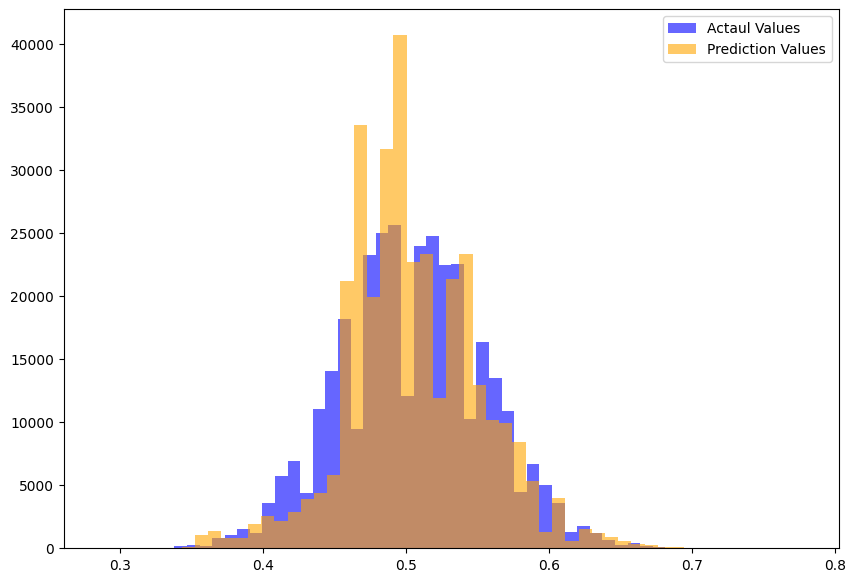

In [61]:
plt.figure(figsize=(10,7))
plt.hist(Y_val.values, bins=50, alpha=0.6, label='Actaul Values', color='blue')
plt.hist(val_pred, bins=50, alpha=0.6, label='Prediction Values', color='orange')
plt.legend()
plt.show()

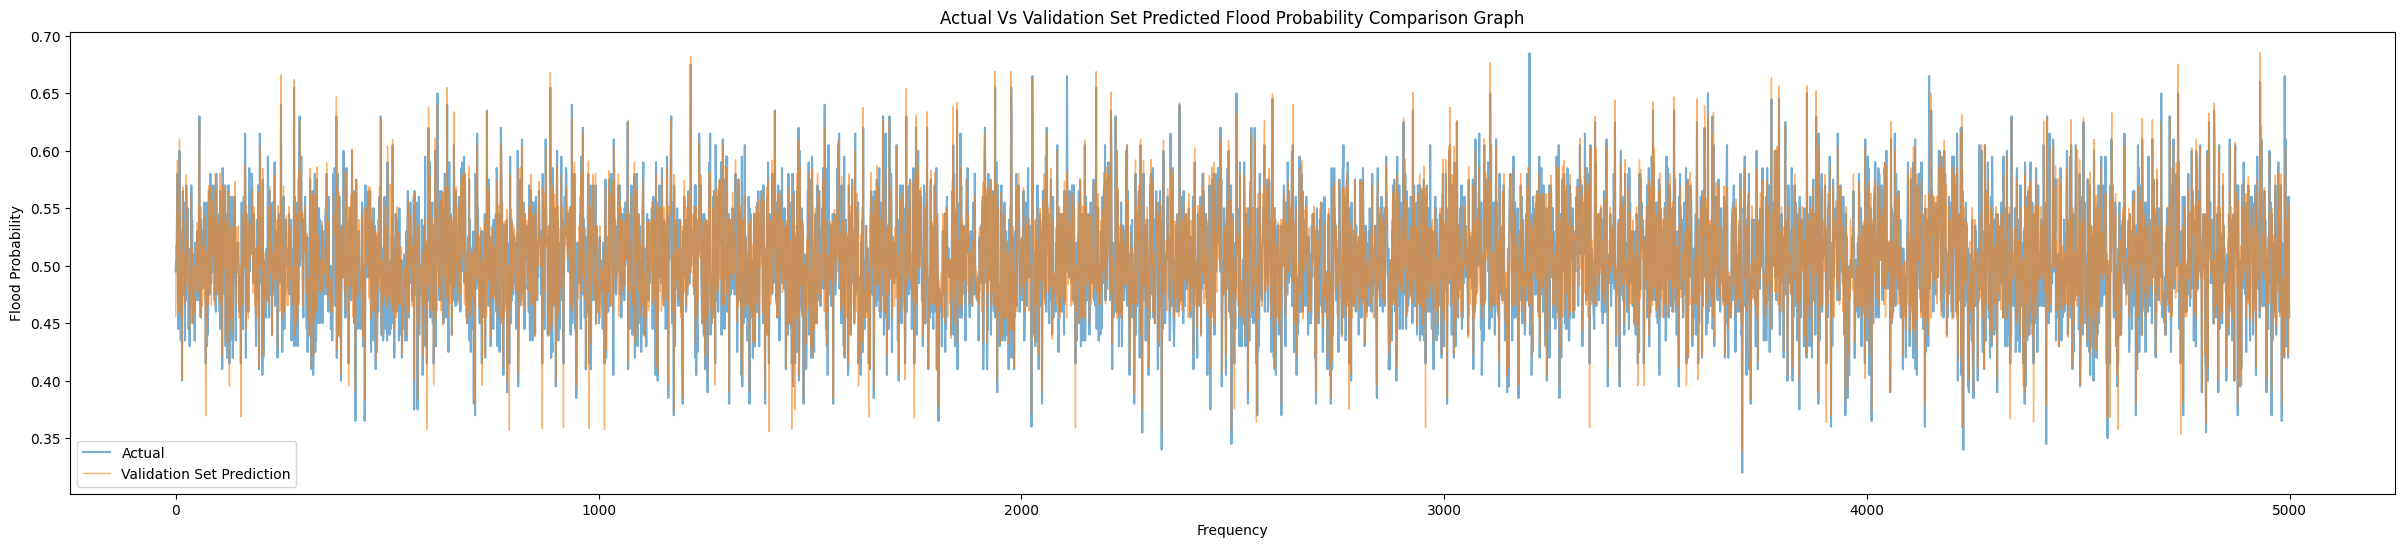

In [62]:
plt.figure(figsize=(30,6))
plt.plot(Y_val.values[:5000], alpha=0.6, label='Actual', linewidth=1.5)
plt.plot(val_pred[:5000], alpha=0.6, label='Validation Set Prediction', linewidth=1)
plt.legend()
plt.xlabel('Frequency')
plt.ylabel('Flood Probability')
plt.title('Actual Vs Validation Set Predicted Flood Probability Comparison Graph')
plt.show()

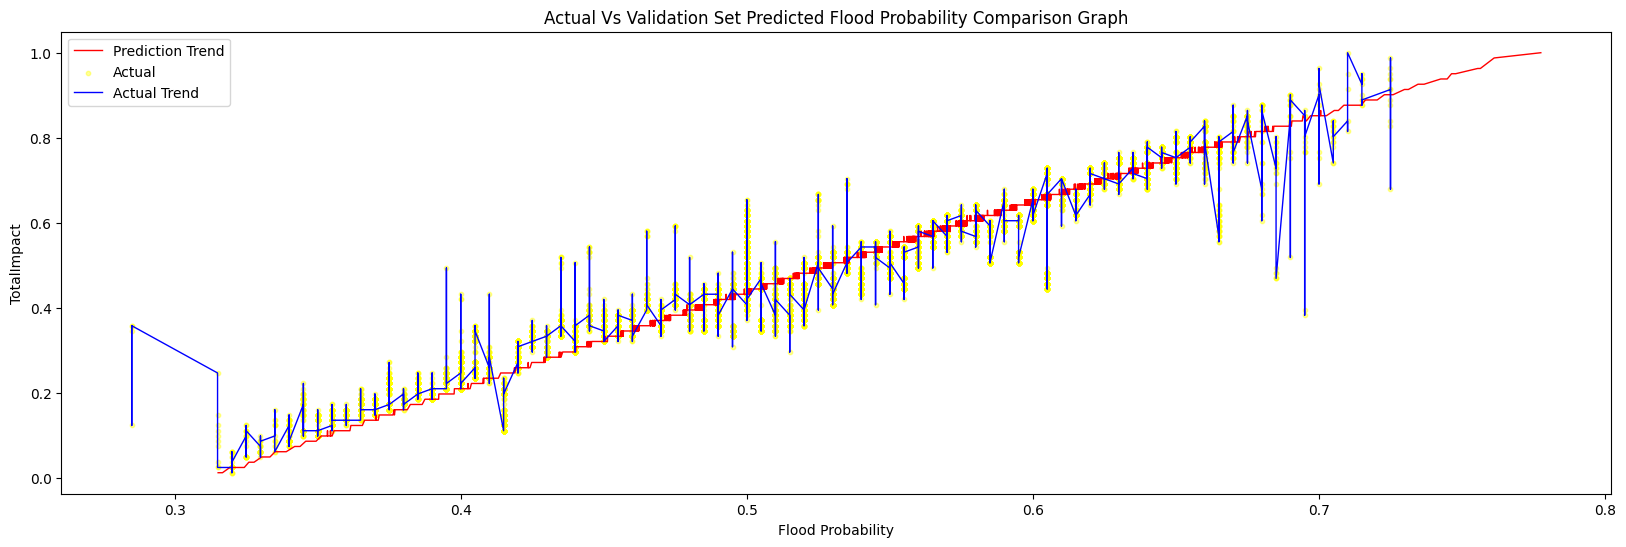

In [63]:
plt.figure(figsize=(20,6))
sort_idx = np.argsort(val_pred)

plt.plot(val_pred[sort_idx], X_val['TotalImpact'].iloc[sort_idx], color='red', label='Prediction Trend', linewidth=1)

plt.scatter(Y_val, X_val['TotalImpact'], alpha=0.4, label='Actual', s=10, color='yellow')

sort_idx = np.argsort(Y_val)
plt.plot(Y_val.iloc[sort_idx], X_val['TotalImpact'].iloc[sort_idx], color='blue', label='Actual Trend', linewidth=1)

plt.legend()
plt.xlabel('Flood Probability')
plt.ylabel('TotalImpact')
plt.title('Actual Vs Validation Set Predicted Flood Probability Comparison Graph')
plt.show()

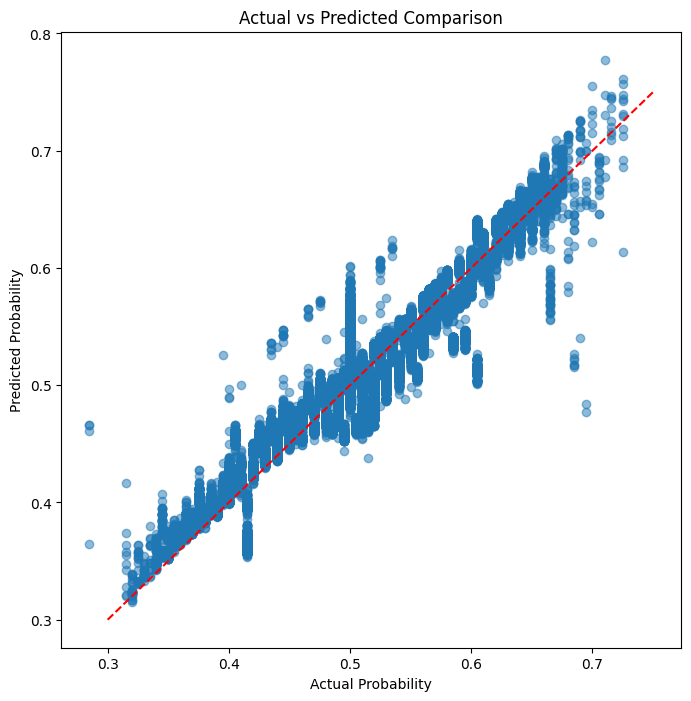

In [64]:
plt.figure(figsize=(8,8))
plt.scatter(Y_val, val_pred, alpha=0.5)
plt.plot([0.3, 0.75], [0.3, 0.75], color='red', linestyle='--') # Identity line
plt.xlabel('Actual Probability')
plt.ylabel('Predicted Probability')
plt.title('Actual vs Predicted Comparison')
plt.show()


# Ridge Regression

In [65]:
from sklearn.linear_model import Ridge

In [66]:
# Ridge model
ridge = Ridge(
    alpha=1.0,          # Regularization strength (higher = more shrinkage)
    fit_intercept=True, # Whether to fit the intercept
    solver='auto',      # 'auto' chooses the best solver based on data
    random_state=42
)

# Train
ridge.fit(X_train, Y_train)

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",42


In [67]:
train_pred = ridge.predict(X_train)
val_pred = ridge.predict(X_val)

In [68]:
train_rmse = rmse(y_true=Y_train, y_pred=train_pred)
val_rmse = rmse(y_true=Y_val, y_pred=val_pred)

print(f'Train RootMeanSquareError: {train_rmse}')
print(f'Validation RootMeanSquareError: {val_rmse}')

Train RootMeanSquareError: 0.020057031825040143
Validation RootMeanSquareError: 0.02005286643580673


In [69]:
train_r2s = r2_score(y_pred=train_pred, y_true=Y_train)
val_r2s = r2_score(y_pred=val_pred, y_true=Y_val)

print(f'Train R² Score: {train_r2s}')
print(f'Validation R² Score: {val_r2s}')

Train R² Score: 0.845520648668318
Validation R² Score: 0.8454913247491834


## Visualisation of the Perdiction and Targets

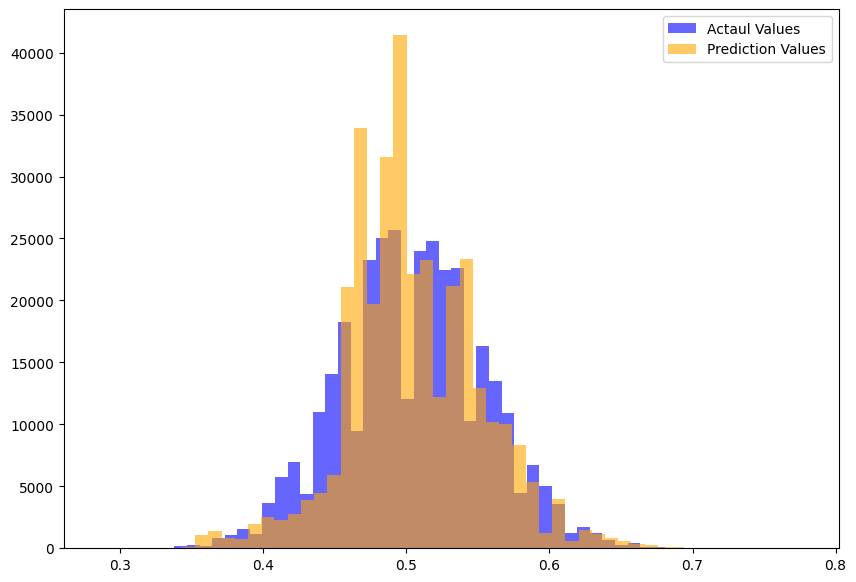

In [70]:
plt.figure(figsize=(10,7))
plt.hist(Y_val.values, bins=50, alpha=0.6, label='Actaul Values', color='blue')
plt.hist(val_pred, bins=50, alpha=0.6, label='Prediction Values', color='orange')
plt.legend()
plt.show()

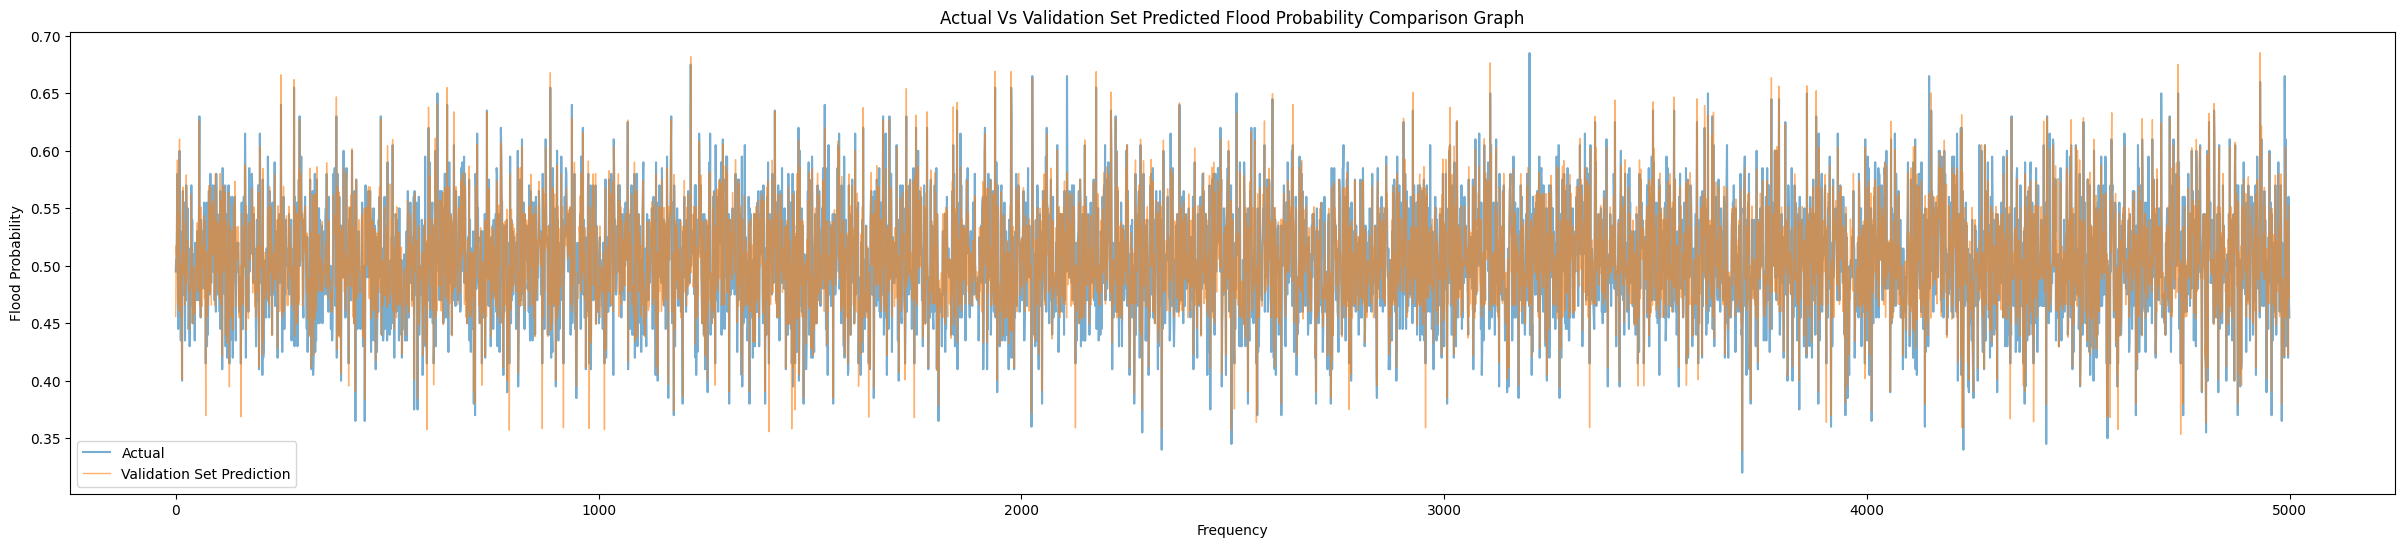

In [71]:
plt.figure(figsize=(30,6))
plt.plot(Y_val.values[:5000], alpha=0.6, label='Actual', linewidth=1.5)
plt.plot(val_pred[:5000], alpha=0.6, label='Validation Set Prediction', linewidth=1)
plt.legend()
plt.xlabel('Frequency')
plt.ylabel('Flood Probability')
plt.title('Actual Vs Validation Set Predicted Flood Probability Comparison Graph')
plt.show()

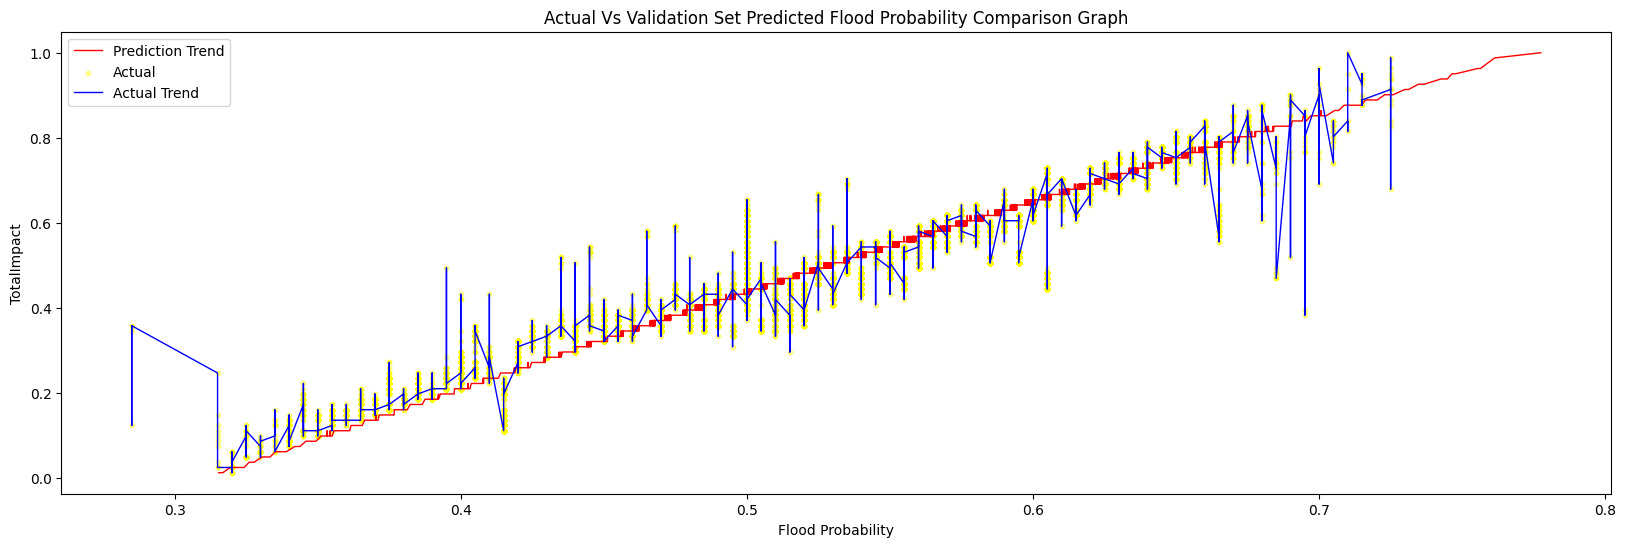

In [72]:
plt.figure(figsize=(20,6))
sort_idx = np.argsort(val_pred)

plt.plot(val_pred[sort_idx], X_val['TotalImpact'].iloc[sort_idx], color='red', label='Prediction Trend', linewidth=1)

plt.scatter(Y_val, X_val['TotalImpact'], alpha=0.4, label='Actual', s=10, color='yellow')

sort_idx = np.argsort(Y_val)
plt.plot(Y_val.iloc[sort_idx], X_val['TotalImpact'].iloc[sort_idx], color='blue', label='Actual Trend', linewidth=1)

plt.legend()
plt.xlabel('Flood Probability')
plt.ylabel('TotalImpact')
plt.title('Actual Vs Validation Set Predicted Flood Probability Comparison Graph')
plt.show()

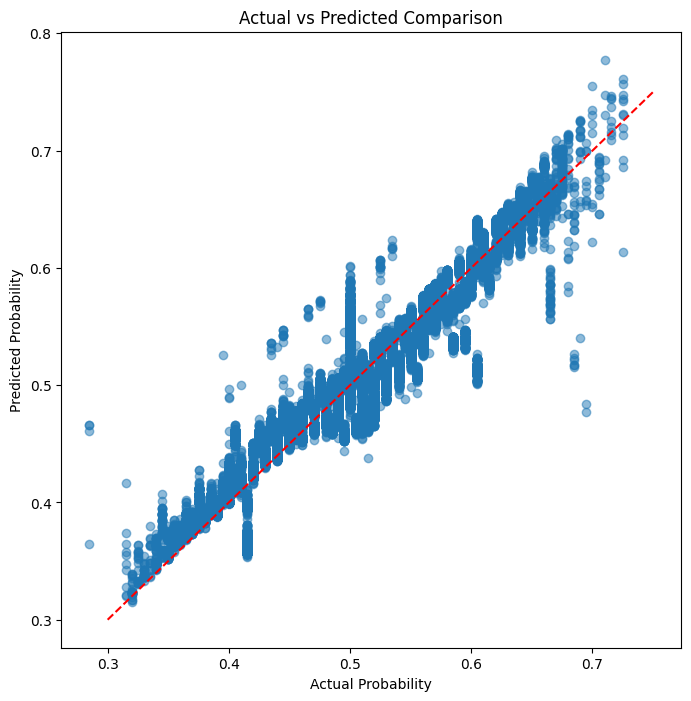

In [73]:
plt.figure(figsize=(8,8))
plt.scatter(Y_val, val_pred, alpha=0.5)
plt.plot([0.3, 0.75], [0.3, 0.75], color='red', linestyle='--') # Identity line
plt.xlabel('Actual Probability')
plt.ylabel('Predicted Probability')
plt.title('Actual vs Predicted Comparison')
plt.show()


# CatBoost

In [74]:
import catboost as cb

In [75]:
cbr = cb.CatBoostRegressor( iterations=1000,  #- Core  #high + early stopping will find the sweet spot
                            learning_rate=0.05,        # 0.05 is faster convergence than 0.01
                            depth=7,                   # 6-8 is ideal; deeper = overfitting
                            random_state=972,
                            thread_count=-1,
                            # --- Regularization ---
                            l2_leaf_reg=3.0,           # L2 on leaf weights (default=3, try 1–10)
                            min_data_in_leaf=15,       # min samples per leaf, prevents overfitting
                            bagging_temperature=0.8,   # randomness in bootstrap (0=deterministic, 1=full random)
                            # --- Sampling ---
                            subsample=0.8,             # row sampling per tree (only works with bootstrap)
                            colsample_bylevel=0.8,     # feature sampling per depth level
                            # --- Speed & Logging ---
                            task_type='CPU',           # change to 'GPU' if available
                            eval_metric='RMSE',
                            verbose=100,               # print every 100 iterations
                            early_stopping_rounds=50,  #  CatBoost supports this in constructor directly
)

In [76]:
cbr.fit(
    X_train, Y_train,
    eval_set=(X_val, Y_val),
    use_best_model=True,
)

0:	learn: 0.0489044	test: 0.0488932	best: 0.0488932 (0)	total: 257ms	remaining: 4m 16s
100:	learn: 0.0186656	test: 0.0186691	best: 0.0186691 (100)	total: 12.7s	remaining: 1m 52s
200:	learn: 0.0185653	test: 0.0185787	best: 0.0185787 (200)	total: 23.7s	remaining: 1m 34s
300:	learn: 0.0185128	test: 0.0185367	best: 0.0185367 (300)	total: 34.6s	remaining: 1m 20s
400:	learn: 0.0184782	test: 0.0185126	best: 0.0185126 (400)	total: 46.5s	remaining: 1m 9s
500:	learn: 0.0184548	test: 0.0185031	best: 0.0185031 (500)	total: 59.3s	remaining: 59.1s
600:	learn: 0.0184341	test: 0.0184957	best: 0.0184957 (600)	total: 1m 11s	remaining: 47.4s
700:	learn: 0.0184176	test: 0.0184919	best: 0.0184919 (700)	total: 1m 22s	remaining: 35.2s
800:	learn: 0.0184011	test: 0.0184887	best: 0.0184887 (796)	total: 1m 33s	remaining: 23.1s
900:	learn: 0.0183850	test: 0.0184859	best: 0.0184858 (896)	total: 1m 44s	remaining: 11.4s
999:	learn: 0.0183698	test: 0.0184842	best: 0.0184841 (974)	total: 1m 55s	remaining: 0us

bestTe

CatBoostRegressor(bagging_temperature=0.8, colsample_bylevel=0.8, depth=7, early_stopping_rounds=50, eval_metric='RMSE', iterations=1000, l2_leaf_reg=3.0, learning_rate=0.05, loss_function='RMSE', min_data_in_leaf=15, random_state=972, subsample=0.8, task_type='CPU', verbose=100)

In [77]:
train_pred = cbr.predict(X_train)
val_pred = cbr.predict(X_val)

In [78]:
train_rmse = rmse(y_true=Y_train, y_pred=train_pred)
val_rmse = rmse(y_true=Y_val, y_pred=val_pred)

print(f'Train RootMeanSquareError: {train_rmse}')
print(f'Validation RootMeanSquareError: {val_rmse}')

Train RootMeanSquareError: 0.018373688079074774
Validation RootMeanSquareError: 0.01848412506717855


In [79]:
train_r2s = r2_score(y_pred=train_pred, y_true=Y_train)
val_r2s = r2_score(y_pred=val_pred, y_true=Y_val)

print(f'Train R² Score: {train_r2s}')
print(f'Validation R² Score: {val_r2s}')

Train R² Score: 0.8703627563355616
Validation R² Score: 0.8687202492882317


##### max_depth = 7, n_estimators = 1000
* RMSE:
    * Train RootMeanSquareError: 0.018699898237821637
    * Validation RootMeanSquareError: 0.0187078024399395

* R2 Score:
    * Train R² Score: 0.8656899553259216
    * Validation R² Score: 0.8655940618526341



## Visualisation of the Perdiction and Targets

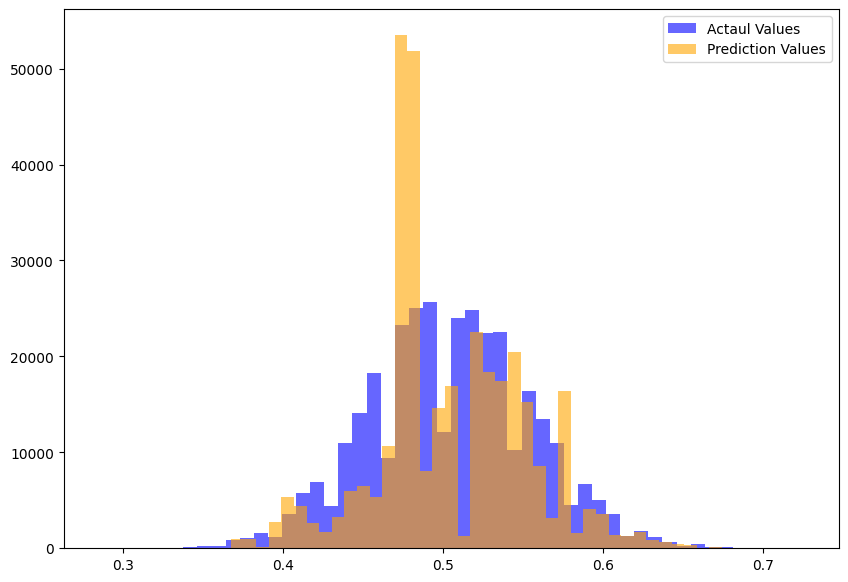

In [80]:
plt.figure(figsize=(10,7))
plt.hist(Y_val.values, bins=50, alpha=0.6, label='Actaul Values', color='blue')
plt.hist(val_pred, bins=50, alpha=0.6, label='Prediction Values', color='orange')
plt.legend()
plt.show()

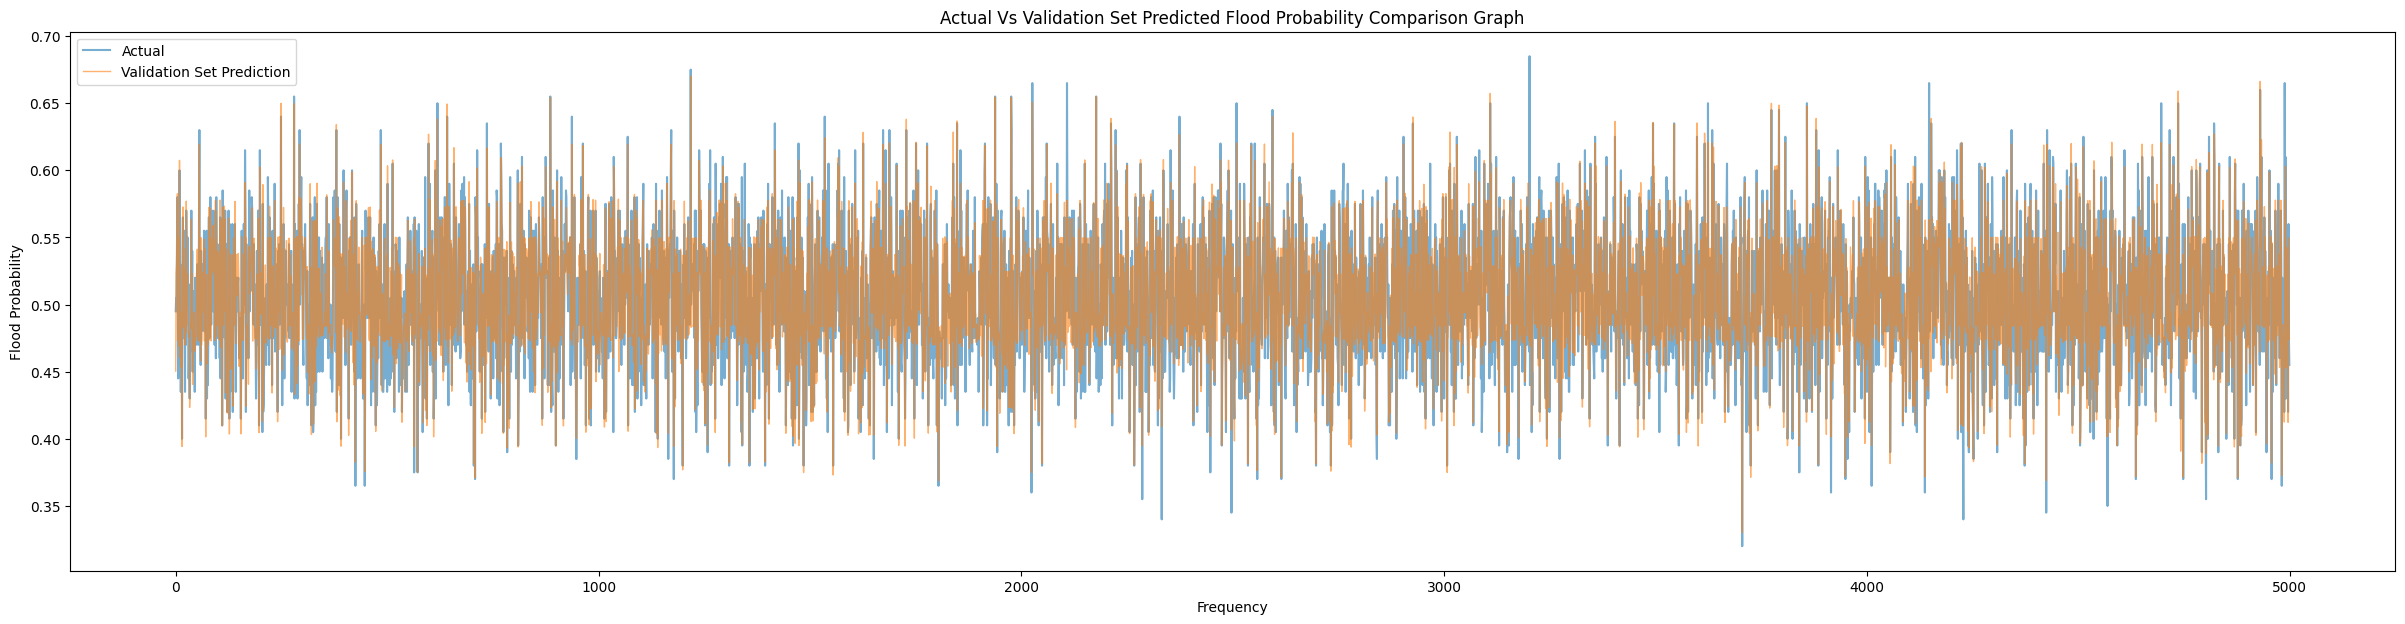

In [81]:
plt.figure(figsize=(30,7))
plt.plot(Y_val.values[:5000], alpha=0.6, label='Actual', linewidth=1.5)
plt.plot(val_pred[:5000], alpha=0.6, label='Validation Set Prediction', linewidth=1)
plt.legend()
plt.xlabel('Frequency')
plt.ylabel('Flood Probability')
plt.title('Actual Vs Validation Set Predicted Flood Probability Comparison Graph')
plt.show()

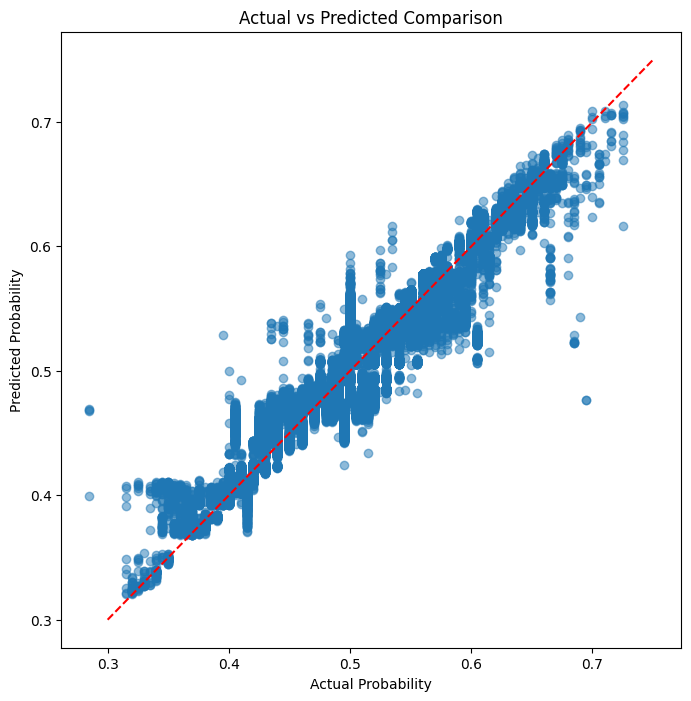

In [82]:
plt.figure(figsize=(8,8))
plt.scatter(Y_val, val_pred, alpha=0.5)
plt.plot([0.3, 0.75], [0.3, 0.75], color='red', linestyle='--') # Identity line
plt.xlabel('Actual Probability')
plt.ylabel('Predicted Probability')
plt.title('Actual vs Predicted Comparison')
plt.show()

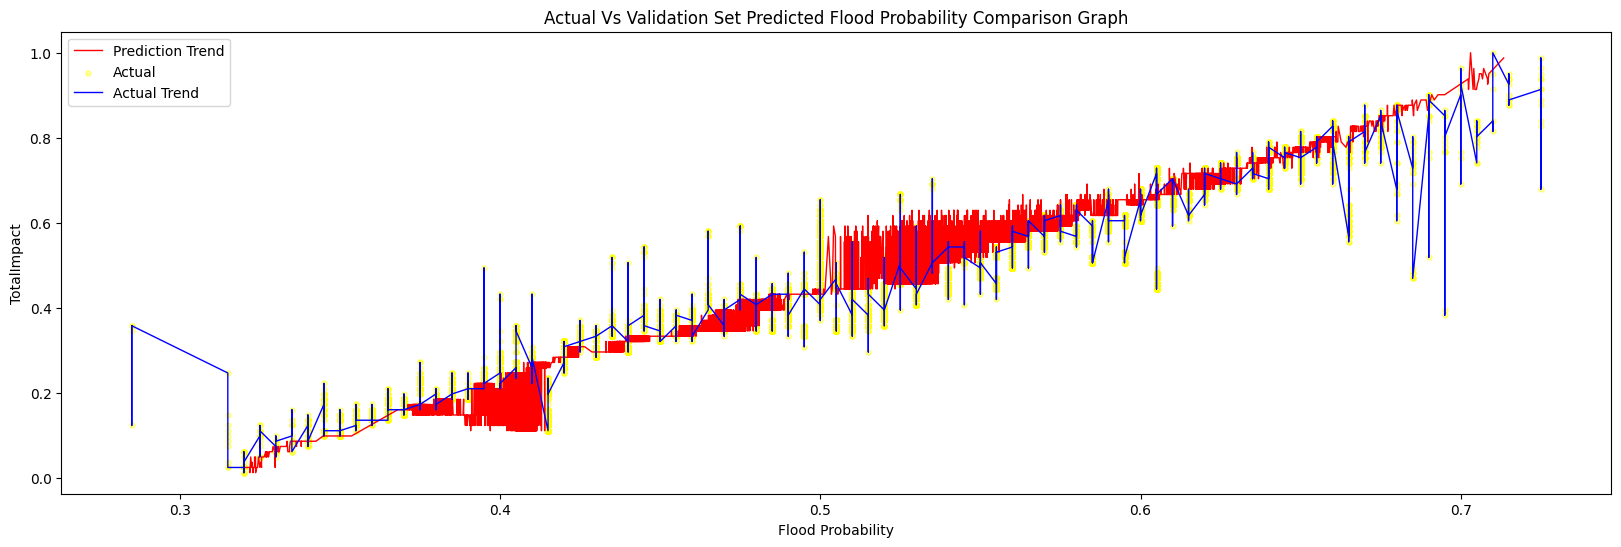

In [83]:
plt.figure(figsize=(20,6))
sort_idx = np.argsort(val_pred)

plt.plot(val_pred[sort_idx], X_val['TotalImpact'].iloc[sort_idx], color='red', label='Prediction Trend', linewidth=1)

plt.scatter(Y_val, X_val['TotalImpact'], alpha=0.4, label='Actual', s=14, color='yellow')

sort_idx = np.argsort(Y_val)
plt.plot(Y_val.iloc[sort_idx], X_val['TotalImpact'].iloc[sort_idx], color='blue', label='Actual Trend', linewidth=1)

plt.legend()
plt.xlabel('Flood Probability')
plt.ylabel('TotalImpact')
plt.title('Actual Vs Validation Set Predicted Flood Probability Comparison Graph')
plt.show()

# ExtraTreeRegressor 

In [84]:
from sklearn.ensemble import ExtraTreesRegressor

In [85]:
etr = ExtraTreesRegressor(n_estimators=200,
                         max_depth=7,
                         n_jobs=-1,
                         verbose=2)

In [86]:
etr.fit(X_train, Y_train)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.


building tree 1 of 200building tree 2 of 200
building tree 3 of 200
building tree 4 of 200

building tree 5 of 200
building tree 6 of 200
building tree 7 of 200
building tree 8 of 200
building tree 9 of 200
building tree 10 of 200
building tree 11 of 200
building tree 12 of 200
building tree 13 of 200
building tree 14 of 200
building tree 15 of 200building tree 16 of 200

building tree 17 of 200
building tree 18 of 200
building tree 19 of 200
building tree 20 of 200
building tree 21 of 200
building tree 22 of 200
building tree 23 of 200
building tree 24 of 200
building tree 25 of 200
building tree 26 of 200
building tree 27 of 200
building tree 28 of 200
building tree 29 of 200


[Parallel(n_jobs=-1)]: Done  17 tasks      | elapsed:   46.6s


building tree 30 of 200
building tree 31 of 200
building tree 32 of 200
building tree 33 of 200
building tree 34 of 200
building tree 35 of 200
building tree 36 of 200
building tree 37 of 200
building tree 38 of 200
building tree 39 of 200
building tree 40 of 200
building tree 41 of 200
building tree 42 of 200
building tree 43 of 200
building tree 44 of 200
building tree 45 of 200
building tree 46 of 200
building tree 47 of 200
building tree 48 of 200
building tree 49 of 200
building tree 50 of 200
building tree 51 of 200
building tree 52 of 200
building tree 53 of 200
building tree 54 of 200
building tree 55 of 200
building tree 56 of 200
building tree 57 of 200
building tree 58 of 200
building tree 59 of 200
building tree 60 of 200
building tree 61 of 200
building tree 62 of 200
building tree 63 of 200
building tree 64 of 200
building tree 65 of 200
building tree 66 of 200
building tree 67 of 200
building tree 68 of 200
building tree 69 of 200
building tree 70 of 200
building tree 71

[Parallel(n_jobs=-1)]: Done 138 tasks      | elapsed:  4.8min


building tree 151 of 200
building tree 152 of 200
building tree 153 of 200
building tree 154 of 200
building tree 155 of 200
building tree 156 of 200
building tree 157 of 200
building tree 158 of 200
building tree 159 of 200
building tree 160 of 200
building tree 161 of 200
building tree 162 of 200
building tree 163 of 200
building tree 164 of 200
building tree 165 of 200
building tree 166 of 200
building tree 167 of 200
building tree 168 of 200
building tree 169 of 200
building tree 170 of 200
building tree 171 of 200
building tree 172 of 200
building tree 173 of 200
building tree 174 of 200
building tree 175 of 200
building tree 176 of 200
building tree 177 of 200
building tree 178 of 200
building tree 179 of 200
building tree 180 of 200
building tree 181 of 200
building tree 182 of 200
building tree 183 of 200
building tree 184 of 200
building tree 185 of 200
building tree 186 of 200
building tree 187 of 200
building tree 188 of 200
building tree 189 of 200
building tree 190 of 200


[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:  6.7min finished


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",7
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the num

In [87]:
train_pred = etr.predict(X_train)
val_pred = etr.predict(X_val)

[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  17 tasks      | elapsed:    0.1s
[Parallel(n_jobs=12)]: Done 138 tasks      | elapsed:    1.4s
[Parallel(n_jobs=12)]: Done 200 out of 200 | elapsed:    2.1s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 138 tasks      | elapsed:    0.5s
[Parallel(n_jobs=12)]: Done 200 out of 200 | elapsed:    0.8s finished


In [88]:
train_rmse = rmse(y_true=Y_train, y_pred=train_pred)
val_rmse = rmse(y_true=Y_val, y_pred=val_pred)

print(f'Train RootMeanSquareError: {train_rmse}')
print(f'Validation RootMeanSquareError: {val_rmse}')

Train RootMeanSquareError: 0.018675848305647638
Validation RootMeanSquareError: 0.01867831360440529


In [89]:
train_r2s = r2_score(y_pred=train_pred, y_true=Y_train)
val_r2s = r2_score(y_pred=val_pred, y_true=Y_val)

print(f'Train R² Score: {train_r2s}')
print(f'Validation R² Score: {val_r2s}')

Train R² Score: 0.8660638578948618
Validation R² Score: 0.8659473905679803


##### max_depth = 7, n_estimators = 1000
* RMSE:
    * Train RootMeanSquareError: 0.018699898237821637
    * Validation RootMeanSquareError: 0.0187078024399395

* R2 Score:
    * Train R² Score: 0.8656899553259216
    * Validation R² Score: 0.8655940618526341



## Visualisation of the Perdiction and Targets

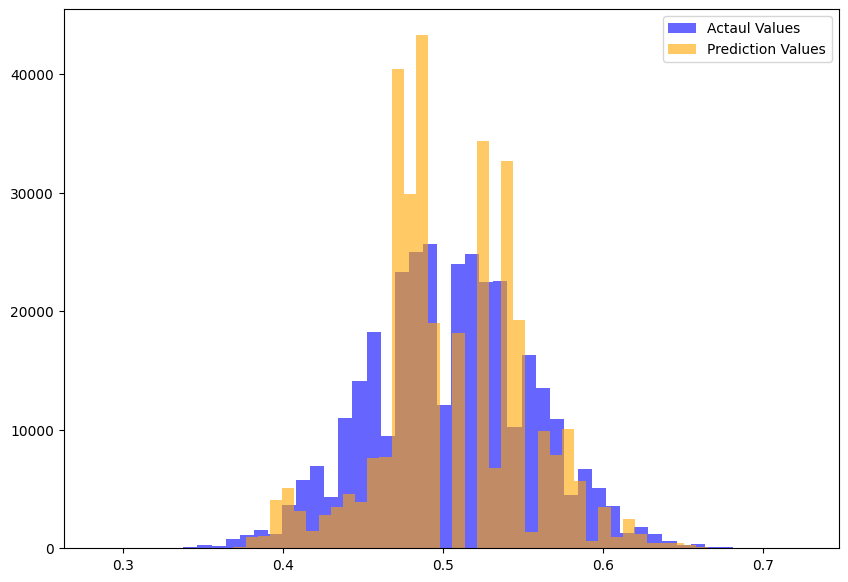

In [90]:
plt.figure(figsize=(10,7))
plt.hist(Y_val.values, bins=50, alpha=0.6, label='Actaul Values', color='blue')
plt.hist(val_pred, bins=50, alpha=0.6, label='Prediction Values', color='orange')
plt.legend()
plt.show()

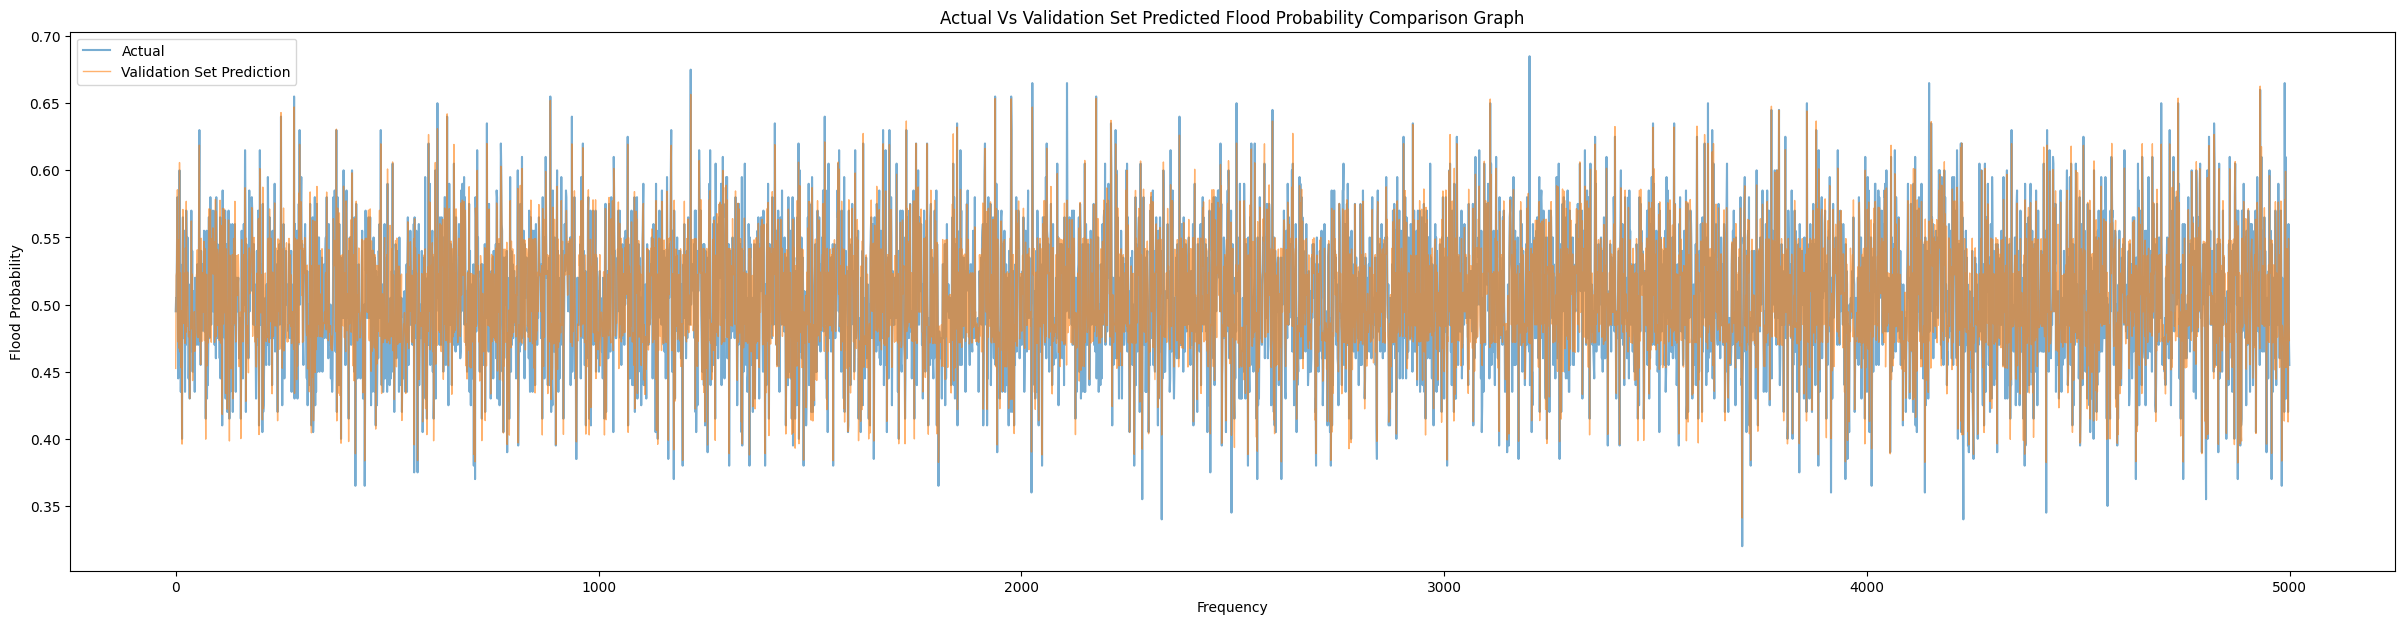

In [91]:
plt.figure(figsize=(30,7))
plt.plot(Y_val.values[:5000], alpha=0.6, label='Actual', linewidth=1.5)
plt.plot(val_pred[:5000], alpha=0.6, label='Validation Set Prediction', linewidth=1)
plt.legend()
plt.xlabel('Frequency')
plt.ylabel('Flood Probability')
plt.title('Actual Vs Validation Set Predicted Flood Probability Comparison Graph')
plt.show()

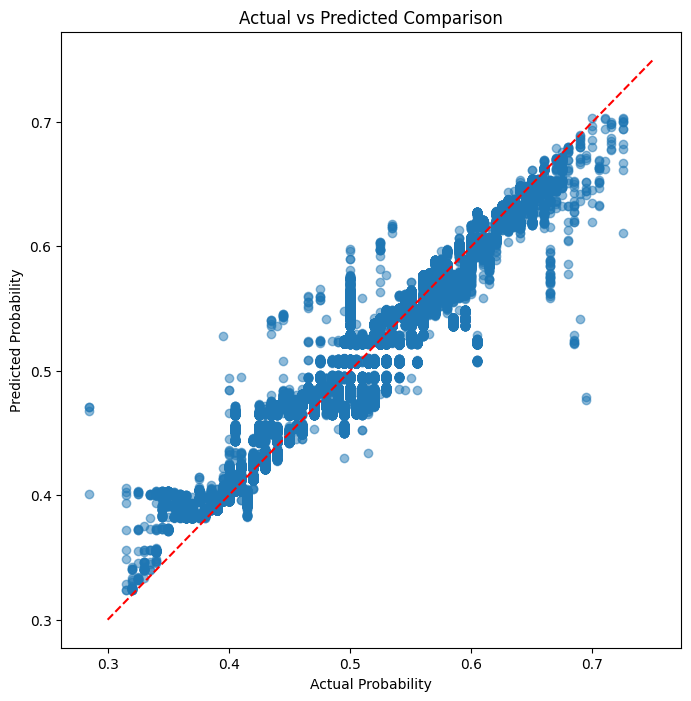

In [92]:
plt.figure(figsize=(8,8))
plt.scatter(Y_val, val_pred, alpha=0.5)
plt.plot([0.3, 0.75], [0.3, 0.75], color='red', linestyle='--') # Identity line
plt.xlabel('Actual Probability')
plt.ylabel('Predicted Probability')
plt.title('Actual vs Predicted Comparison')
plt.show()

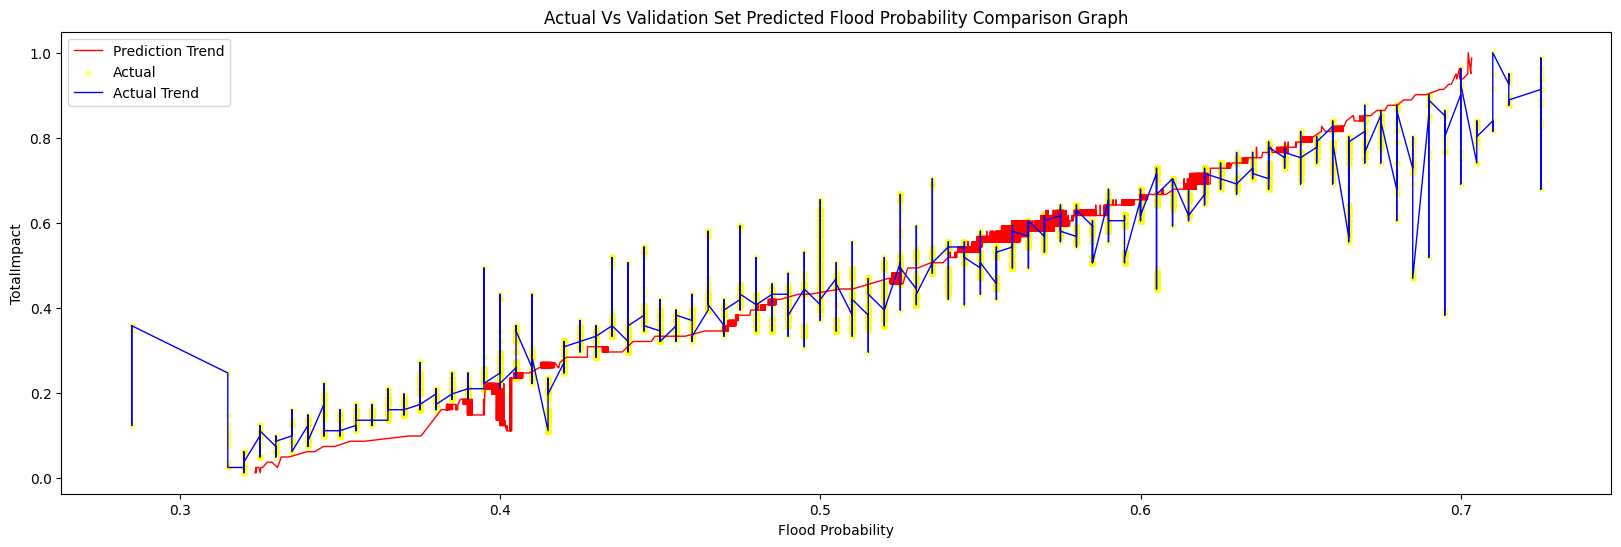

In [93]:
plt.figure(figsize=(20,6))
sort_idx = np.argsort(val_pred)

plt.plot(val_pred[sort_idx], X_val['TotalImpact'].iloc[sort_idx], color='red', label='Prediction Trend', linewidth=1)

plt.scatter(Y_val, X_val['TotalImpact'], alpha=0.4, label='Actual', s=14, color='yellow')

sort_idx = np.argsort(Y_val)
plt.plot(Y_val.iloc[sort_idx], X_val['TotalImpact'].iloc[sort_idx], color='blue', label='Actual Trend', linewidth=1)

plt.legend()
plt.xlabel('Flood Probability')
plt.ylabel('TotalImpact')
plt.title('Actual Vs Validation Set Predicted Flood Probability Comparison Graph')
plt.show()

# RandomForest

In [94]:
from sklearn.ensemble import RandomForestRegressor

In [95]:
rfg = RandomForestRegressor(n_estimators=200,
                            max_depth=15,
                            n_jobs=-1,
                            verbose=1)

In [ ]:
rfg.fit(X_train, Y_train)

In [ ]:
train_pred = rfg.predict(X_train)
val_pred = rfg.predict(X_val)

In [ ]:
train_rmse = rmse(y_true=Y_train, y_pred=train_pred)
val_rmse = rmse(y_true=Y_val, y_pred=val_pred)

print(f'Train RootMeanSquareError: {train_rmse}')
print(f'Validation RootMeanSquareError: {val_rmse}')

In [ ]:
train_r2s = r2_score(y_pred=train_pred, y_true=Y_train)
val_r2s = r2_score(y_pred=val_pred, y_true=Y_val)

print(f'Train R² Score: {train_r2s}')
print(f'Validation R² Score: {val_r2s}')

##### max_depth = 7, n_estimators = 1000
* RMSE:
    * Train RootMeanSquareError: 0.018699898237821637
    * Validation RootMeanSquareError: 0.0187078024399395

* R2 Score:
    * Train R² Score: 0.8656899553259216
    * Validation R² Score: 0.8655940618526341



## Visualisation of the Perdiction and Targets

In [ ]:
plt.figure(figsize=(10,7))
plt.hist(Y_val.values, bins=50, alpha=0.6, label='Actaul Values', color='blue')
plt.hist(val_pred, bins=50, alpha=0.6, label='Prediction Values', color='orange')
plt.legend()
plt.show()

In [ ]:
plt.figure(figsize=(30,7))
plt.plot(Y_val.values[:5000], alpha=0.6, label='Actual', linewidth=1.5)
plt.plot(val_pred[:5000], alpha=0.6, label='Validation Set Prediction', linewidth=1)
plt.legend()
plt.xlabel('Frequency')
plt.ylabel('Flood Probability')
plt.title('Actual Vs Validation Set Predicted Flood Probability Comparison Graph')
plt.show()

In [ ]:
plt.figure(figsize=(8,8))
plt.scatter(Y_val, val_pred, alpha=0.5)
plt.plot([0.3, 0.75], [0.3, 0.75], color='red', linestyle='--') # Identity line
plt.xlabel('Actual Probability')
plt.ylabel('Predicted Probability')
plt.title('Actual vs Predicted Comparison')
plt.show()

In [ ]:
plt.figure(figsize=(20,6))
sort_idx = np.argsort(val_pred)

plt.plot(val_pred[sort_idx], X_val['TotalImpact'].iloc[sort_idx], color='red', label='Prediction Trend', linewidth=1)

plt.scatter(Y_val, X_val['TotalImpact'], alpha=0.4, label='Actual', s=14, color='yellow')

sort_idx = np.argsort(Y_val)
plt.plot(Y_val.iloc[sort_idx], X_val['TotalImpact'].iloc[sort_idx], color='blue', label='Actual Trend', linewidth=1)

plt.legend()
plt.xlabel('Flood Probability')
plt.ylabel('TotalImpact')
plt.title('Actual Vs Validation Set Predicted Flood Probability Comparison Graph')
plt.show()

# Using K-Fold to create model from multiple models

In [ ]:
from sklearn.model_selection import KFold
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
import xgboost
import lightgbm as lgb
import catboost as cb

# ------------ 1. Define Base Models ------------ 
models = {
    'xgbr': xgboost.XGBRegressor( n_estimators=800, max_depth=7, learning_rate=0.01, random_state=22, n_jobs=-1),
    'lgbmr': lgb.LGBMRegressor( n_estimators=800, max_depth=8, learning_rate=0.01, random_state=423, n_jobs=-1),
    'catboost': cb.CatBoostRegressor(iterations=250, depth=7, learning_rate=0.01, random_state=972, thread_count=-1),
    'linearReg' : LinearRegression(n_jobs=-1),
    'etr': ExtraTreesRegressor( n_estimators=200, max_depth=9, random_state=742, n_jobs=-1),
    'ridgeReg': Ridge(alpha=1.0, fit_intercept=True, solver='auto', random_state=42
),
}

# ------------ 2. K-Fold Setup ------------ 

kf = KFold(n_splits=5, shuffle=True, random_state=572)

oof_preds = {}
val_preds = {}

# ------------ 3. Train Base Models ------------ 
for name, model in models.items():
    print(f"\n----------------> Training {name}...")
    
    oof_pred = np.zeros(len(X_train))
    val_pred = np.zeros(len(X_val))
    
    for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)):
        print(f"\n  Fold {fold+1}")
        
        # Split data
        X_tr = X_train.iloc[train_idx]
        X_fold_val = X_train.iloc[val_idx]
        y_tr = Y_train.iloc[train_idx]
        y_fold_val = Y_train.iloc[val_idx]
        
        # Fit model (safe for all models)
        model.fit(X_tr, y_tr)
        
        # OOF predictions (for meta model training)
        oof_pred[val_idx] = model.predict(X_fold_val)
        
        # Validation predictions (for final stacking)
        val_pred += model.predict(X_val) / kf.n_splits
    
    oof_preds[name] = oof_pred
    val_preds[name] = val_pred

print('\n\nK-Fold training completed')

# ------------ 4. Create Stacking Dataset ------------ 
print('\n\nStacking Dataset...')
stack_train = pd.DataFrame(oof_preds)
stack_val = pd.DataFrame(val_preds)
print('Stacking Completed...')


# ------------ 5. Train Meta Model ------------ 
print('\n\nCreating Meta Model...')
meta_model = Ridge(alpha=1.0)
print('Meta Model Created')
meta_model.fit(stack_train, Y_train)


# ------------ 6. Final Predictions ------------ 
print('\nPredicting...')
train_pred = meta_model.predict(stack_train)
val_pred = meta_model.predict(stack_val)
print('Predicting Completed')


# ✅ FIX Bug 4: Retrain each base model on the FULL X_train
# The K-Fold loop above only saved the last fold's model state.
# For correct test predictions, each model must see all training data.
print("\n\nRetraining base models on full X_train for test prediction...")
final_models = {}
for name, model in models.items():
    print(f"  Retraining {name}...")
    model.fit(X_train, Y_train)
    final_models[name] = model
print("Retraining complete.")

# Override models dict with fully-trained models
models = final_models


In [ ]:
train_rmse = rmse(y_true=Y_train, y_pred=train_pred)
val_rmse = rmse(y_true=Y_val, y_pred=val_pred)

print(f'Train RootMeanSquareError: {train_rmse}')
print(f'Validation RootMeanSquareError: {val_rmse}')

In [ ]:
train_r2s = r2_score(y_pred=train_pred, y_true=Y_train)
val_r2s = r2_score(y_pred=val_pred, y_true=Y_val)

print(f'Train R² Score: {train_r2s}')
print(f'Validation R² Score: {val_r2s}')

k-fold splitting = 5
```
models = {

    'xgbr': xgboost.XGBRegressor( n_estimators=800, max_depth=7, learning_rate=0.01, random_state=42, n_jobs=-1),

    'lgbmr': lgb.LGBMRegressor( n_estimators=800, max_depth=8, learning_rate=0.01, random_state=42, n_jobs=-1),

    'catboost': cb.CatBoostRegressor(iterations=700, depth=7, learning_rate=0.01, random_state=42, thread_count=-1),

    'rfg': RandomForestRegressor( n_estimators=500, max_depth=10, random_state=42, n_jobs=-1),

    'etr': ExtraTreesRegressor( n_estimators=400, max_depth=10, random_state=42, n_jobs=-1)

}
```


### RMSE:
* Train RootMeanSquareError: 0.018494681188252572
* Validation RootMeanSquareError: 0.018490312240201062

R2Score:
* Train R² Score: 0.8686497787683121
* Validation R² Score: 0.8686323482952483


## Visualisation of the Perdiction and Targets

In [ ]:
plt.figure(figsize=(30,7))
plt.plot(Y_val.values[:5000], alpha=0.6, label='Actual', linewidth=1.5)
plt.plot(val_pred[:5000], alpha=0.6, label='Validation Set Prediction', linewidth=1)
plt.legend()
plt.xlabel('Frequency')
plt.ylabel('Flood Probability')
plt.title('Actual Vs Validation Set Predicted Flood Probability Comparison Graph')
plt.show()

In [ ]:
plt.figure(figsize=(10,7))
plt.hist(Y_val.values, bins=50, alpha=0.6, label='Actaul Values', color='blue')
plt.hist(val_pred, bins=50, alpha=0.6, label='Prediction Values', color='orange')
plt.legend()
plt.show()

In [ ]:
plt.figure(figsize=(8,8))
plt.scatter(Y_val, val_pred, alpha=0.5)
plt.plot([0.3, 0.75], [0.3, 0.75], color='red', linestyle='--') # Identity line
plt.xlabel('Actual Probability')
plt.ylabel('Predicted Probability')
plt.title('Actual vs Predicted Comparison')
plt.show()

In [ ]:
plt.figure(figsize=(20,6))
sort_idx = np.argsort(val_pred)

plt.plot(val_pred[sort_idx], X_val['TotalImpact'].iloc[sort_idx], color='red', label='Prediction Trend', linewidth=1)

plt.scatter(Y_val, X_val['TotalImpact'], alpha=0.4, label='Actual', s=14, color='yellow')

sort_idx = np.argsort(Y_val)
plt.plot(Y_val.iloc[sort_idx], X_val['TotalImpact'].iloc[sort_idx], color='blue', label='Actual Trend', linewidth=1)

plt.legend()
plt.xlabel('Flood Probability')
plt.ylabel('TotalImpact')
plt.title('Actual Vs Validation Set Predicted Flood Probability Comparison Graph')
plt.show()

# Saving model

In [ ]:
import joblib

# ========== SAVING TRAINED MODELS ==========
print("Saving trained models...")

# Save base models dictionary
joblib.dump(models, 'base_models.pkl')
print("  Base models saved as 'base_models.pkl'")

# Save meta model
joblib.dump(meta_model, 'meta_model_alpha.pkl')
print("  Meta model saved as 'meta_model.pkl'")

print("\nModels saved successfully!")


# Loading the saved model

In [ ]:
# ========== LOADING SAVED MODELS ==========
print("Loading saved models...")
base_models_loaded = joblib.load('base_models.pkl')
meta_model_loaded = joblib.load('meta_model.pkl')
print("Models loaded successfully!\n")

# ========== MAKING PREDICTIONS ON TEST DATA ==========
print("Making predictions on test data...")

# Step 1: Get predictions from all base models on test data
base_preds_test = {}
for name, model in base_models_loaded.items():
    print(f"  Predicting with {name}...")
    base_preds_test[name] = model.predict(test_input_df)

# Step 2: Stack base predictions into a DataFrame
stack_X_test = pd.DataFrame(base_preds_test)
print(f"\nStacked test predictions shape: {stack_X_test.shape}")
print(f"Columns: {stack_X_test.columns.tolist()}\n")

# Step 3: Get final predictions from meta model
final_predictions = meta_model_loaded.predict(stack_X_test)
print(f"Final predictions shape: {final_predictions.shape}")
print(f"Sample predictions: {final_predictions[:5]}\n")

# ========== CREATE SUBMISSION FILE ==========
print("Creating submission file...")
submission = pd.DataFrame({
    'id': test_df['id'],
    'FloodProbability': final_predictions
})

submission.to_csv('submission_stacking.csv', index=False)
print("Submission saved as 'submission_stacking.csv'")
print(f"\nSubmission preview:\n{submission.head()}")
